In [ ]:
# imports
from datetime import timedelta
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns
import data_preprocessing
from data_integration import combine_data, read_data

## Read data

In [ ]:
# reads all datasets, if they are stored in the required folder DiaData/datasets for T1D/...
subdatabaseII = pl.read_csv("DiaData/datasets for T1D/SDBII.csv")
# 
subdatabaseII = subdatabaseII.sort(["PtID", "ts"])
# converts the timestamp column to datetime
subdatabaseII = subdatabaseII.to_pandas()
subdatabaseII["ts"] = pd.to_datetime(subdatabaseII["ts"])

## Outlier detection

In [4]:
# calls function remove_outliers() for glucose and heart rate columns based on the IQR method
data_cleaned_glc = data_preprocessing.remove_outliers(subdatabaseII, value = "GlucoseCGM", modus = "glucose", subject = "PtID")
data_cleaned = data_preprocessing.remove_outliers(data_cleaned_glc, value = "HR", modus = "vitals", subject = "PtID")  

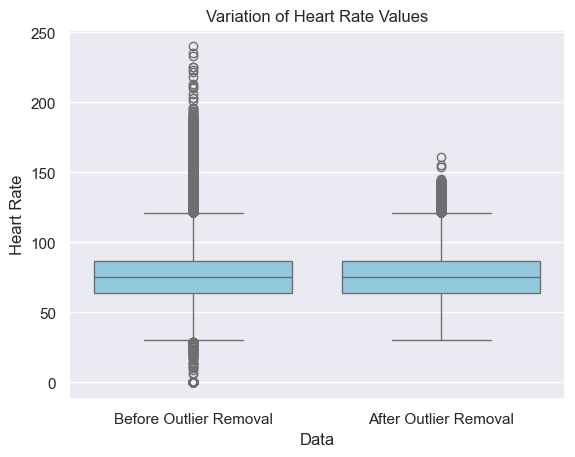

In [ ]:
# prints the boxplots for heartrate values before and after outlier removal
# first the raw data is copied and marked
sdbII_copy = subdatabaseII.copy()
sdbII_copy['Data'] = 'Before Outlier Removal'

# then the preprocessed data is copied and marked
sdbII_cleaned_copy = data_cleaned.copy()
sdbII_cleaned_copy['Data'] = 'After Outlier Removal'

# both are combined to the same dataset to enable boxplots next to each other
combined_both = pd.concat([sdbII_copy, sdbII_cleaned_copy])
combined_both = combined_both.reset_index(drop=True)

# boxplots grouped by the data type (before or after outlier removal) are plotted 
sns.set_theme(style="darkgrid")
sns.boxplot(x='Data', y='HR', data=combined_both,showfliers=True, color='skyblue')
plt.title('Comparison of Value Distributions')
plt.title("Variation of Heart Rate Values")
plt.suptitle("")  
plt.ylabel("Heart Rate")
plt.show()

## Missing value imputation

In [ ]:
# linear interpolation is used for gaps which are less than 30 minute (6 consecuitve datapoints)
# first for glucose then for heart rate values by callign the function gap_limited_interpolation()
sdbII_interpolated = data_cleaned.copy()
sdbII_interpolated = sdbII_interpolated.sort_values("ts")
sdbII_interpolated['GlucoseCGM'] = sdbII_interpolated.groupby('PtID')['GlucoseCGM'].transform(
    lambda x: data_preprocessing.gap_limited_interpolation(x, limit=6)
)

sdbII_interpolated['HR'] = sdbII_interpolated.groupby('PtID')['HR'].transform(
    lambda x: data_preprocessing.gap_limited_interpolation(x, limit=6)
)

# then gaps between 30 and 120 min are imputed with stine interpolation separately for glucose and heart rate 
sdbII_interpolated_stine = sdbII_interpolated.groupby("PtID", group_keys=False).apply(lambda x: data_preprocessing.interpolate_stineman_group(x, timestamp = "ts", value = "GlucoseCGM", llimit=6, ulimit=24))
# index is sorted 
sdbII_interpolated_stine = sdbII_interpolated_stine.sort_index()
sdbII_interpolated_stine = sdbII_interpolated.groupby("PtID", group_keys=False).apply(lambda x: data_preprocessing.interpolate_stineman_group(x, timestamp = "ts", value = "HR", llimit=6, ulimit=24))
# index is sorted 
sdbII_interpolated_stine = sdbII_interpolated_stine.sort_index()

In [11]:
# as a comparison, a copy of the cleaned dataset before imputation is made
only_interpolated = data_cleaned.copy()

# missing values of this copy are imputed with linear interpolation for all gaps lengths
only_interpolated['GlucoseCGM'] = only_interpolated.groupby('PtID')['GlucoseCGM'].transform(lambda group: group.interpolate(method='linear'))
only_interpolated['HR'] = only_interpolated.groupby('PtID')['HR'].transform(lambda group: group.interpolate(method='linear'))

/var/folders/t1/sgksm9r9385br4pts_lckj1w0000gn/T/ipykernel_3377/895982951.py:58: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=90)
/var/folders/t1/sgksm9r9385br4pts_lckj1w0000gn/T/ipykernel_3377/895982951.py:89: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(ax2.get_xticklabels())


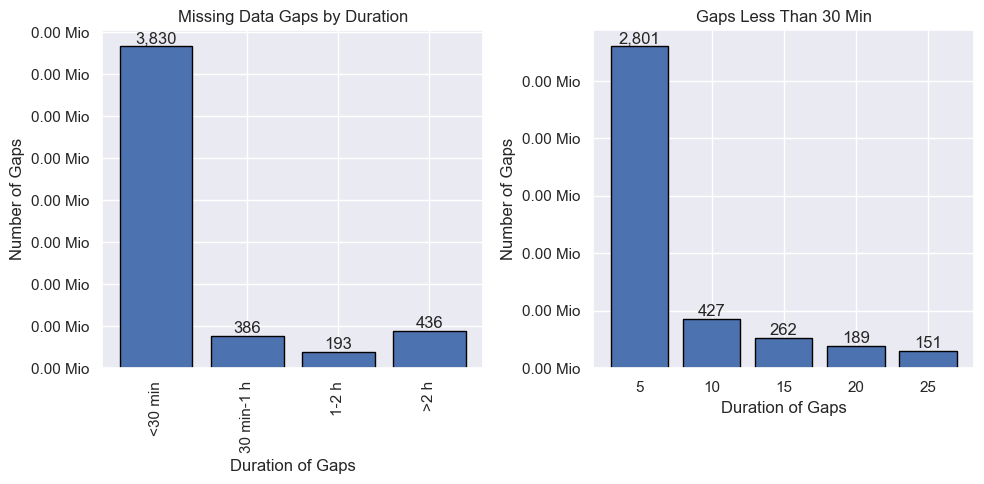

In [ ]:
# plots missing values to explore the data quality

# function to show both value and percentage
def make_autopct(values):
    def my_autopct(pct):
        total = sum(values)
        val = int(round(pct * total / 100.0))
        return f"{val} ({pct:.1f}%)"
    return my_autopct

# the dataframe is copied
df_glc_missing = subdatabaseII.copy()
# first, missing blocks are identified 
df_glc_missing["missing"] = df_glc_missing["HR"].isna()

# uses groupby with cumsum to find continuous blocks
df_glc_missing["gap_id"] = (df_glc_missing["missing"] != df_glc_missing["missing"].shift()).cumsum()
# groups by the identified gaps
na_groups = df_glc_missing[df_glc_missing["missing"]].groupby("gap_id").size().reset_index(name="missing_count")
# one row of missing data equals 5 minutes, so the length of gap is multiplied by 5
na_groups["missing_count_time"] = na_groups["missing_count"] * 5

# categorizes durations based on specified bins and labels
bins = [0,30,60,120,na_groups["missing_count_time"].max()]
labels = [
    "<30 min",
    "30 min-1 h",
    "1-2 h",
    ">2 h"
]
# converts durations to timedelta seconds for binning
duration_bins = pd.cut(na_groups["missing_count_time"], bins=bins, labels=labels, right=False)

# counts number of gaps per duration range
gap_counts = duration_bins.value_counts().sort_index()

# creates the bin groups
na_groups["MissingGroup"] = pd.cut(na_groups["missing_count_time"], bins=bins, labels=labels, right=False)
# filters to only less than 30 minute gaps
count_30_missing = na_groups[na_groups["MissingGroup"] ==  "<30 min"]["missing_count_time"].value_counts()

# plots the missing values count per created group and for the second group of less than 30 minutes in 5 minute intervals
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

# plots the barchart of all missing value groups
ax1.bar(gap_counts.index.astype(str), gap_counts.values, edgecolor="black")
ax1.set_title("Missing Data Gaps by Duration")
ax1.set_xlabel("Duration of Gaps")
ax1.set_ylabel("Number of Gaps")

# formatter function
def millions(x, pos):
    return f"{x*1e-6:.2f} Mio"

# applyies formatter to axis
ax1.yaxis.set_major_formatter(FuncFormatter(millions))
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=90)
    
for bar in ax1.patches:
    height = bar.get_height()
    label = f"{int(height):,}"  
    ax1.text(
        bar.get_x() + bar.get_width() / 2,  
        height,                            
        label,                             
        ha="center", va="bottom"
    )

count_30_missing = count_30_missing.sort_index()
# plots the missing values distribution less than 30 minutes as a bar chart
ax2.bar(count_30_missing.index.astype(str), count_30_missing.values, width=0.8, edgecolor="black")
ax2.set_title("Gaps Less Than 30 Min")
ax2.set_xlabel("Duration of Gaps")
ax2.set_ylabel("Number of Gaps")

for bar in ax2.patches:
    height = bar.get_height()
    label = f"{int(height):,}"  
    ax2.text(
        bar.get_x() + bar.get_width() / 2,  
        height,                            
        label,                            
        ha="center", va="bottom"
    )

# applies formatter to axis 
ax2.yaxis.set_major_formatter(FuncFormatter(millions))
ax2.set_xticklabels(ax2.get_xticklabels())

# layout
plt.tight_layout()
plt.show()

/var/folders/t1/sgksm9r9385br4pts_lckj1w0000gn/T/ipykernel_3377/3001251455.py:57: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=90)
/var/folders/t1/sgksm9r9385br4pts_lckj1w0000gn/T/ipykernel_3377/3001251455.py:88: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(ax2.get_xticklabels())


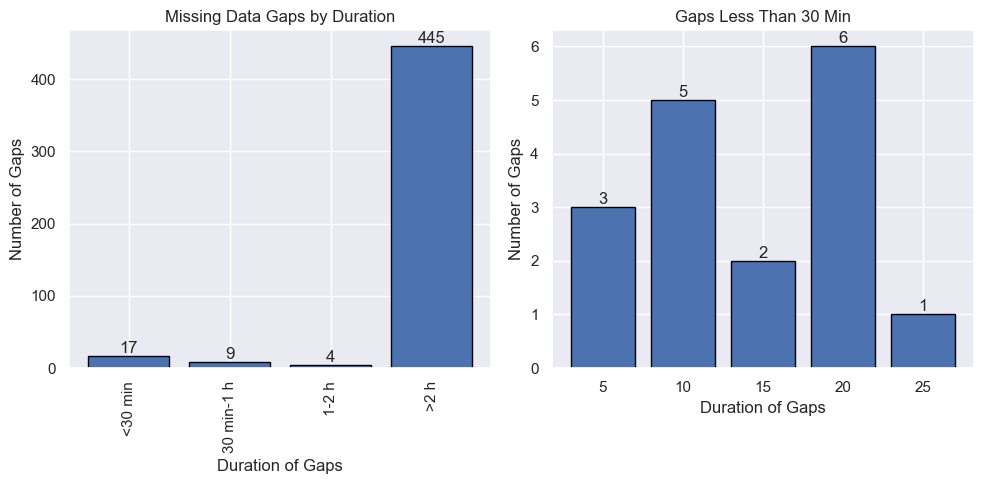

In [ ]:
# plots missing values to explore the data quality

# function to show both value and percentage
def make_autopct(values):
    def my_autopct(pct):
        total = sum(values)
        val = int(round(pct * total / 100.0))
        val_mio = round(val / 1_000_000, 1)
        return f"{val} ({pct:.1f}%)"
    return my_autopct

# the dataframe is copied
df_hr_missing = sdbII_interpolated_stine.copy()
# first, missing blocks are identified 
df_hr_missing["missing"] = df_hr_missing["HR"].isna()

# uses groupby with cumsum to find continuous blocks
df_hr_missing["gap_id"] = (df_hr_missing["missing"] != df_hr_missing["missing"].shift()).cumsum()
# groups by the identified gaps
na_groups = df_hr_missing[df_hr_missing["missing"]].groupby("gap_id").size().reset_index(name="missing_count")
# one row of missing data equals 5 minutes, so the length of gap is multiplied by 5
na_groups["missing_count_time"] = na_groups["missing_count"] * 5

# categorizes durations based on specified bins and labels
bins = [0,30,60,120,na_groups["missing_count_time"].max()]
labels = [
    "<30 min",
    "30 min-1 h",
    "1-2 h",
    ">2 h"
]
# converts durations to timedelta seconds for binning
duration_bins = pd.cut(na_groups["missing_count_time"], bins=bins, labels=labels, right=False)

# counts number of gaps per duration range
gap_counts = duration_bins.value_counts().sort_index()

# creates the bin groups
na_groups["MissingGroup"] = pd.cut(na_groups["missing_count_time"], bins=bins, labels=labels, right=False)
# filters to only less than 30 minute gaps
count_30_missing = na_groups[na_groups["MissingGroup"] ==  "<30 min"]["missing_count_time"].value_counts()

# plots the missing values count per created group and for the second group of less than 30 minutes in 5 minute intervals
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

# plots the barchart of all missing value groups
ax1.bar(gap_counts.index.astype(str), gap_counts.values, edgecolor="black")
ax1.set_title("Missing Data Gaps by Duration")
ax1.set_xlabel("Duration of Gaps")
ax1.set_ylabel("Number of Gaps")

# formatter function
def millions(x, pos):
    return f"{x*1e-6:.2f} Mio"

# applyies formatter to axis
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=90)

# plots the numbers on the bar
for bar in ax1.patches:
    height = bar.get_height()
    label = f"{int(height):,}"  
    ax1.text(
        bar.get_x() + bar.get_width() / 2,  
        height,                           
        label,                             
        ha="center", va="bottom"
    )

count_30_missing = count_30_missing.sort_index()
# plots the missing values distribution less than 30 minutes as a bar chart
ax2.bar(count_30_missing.index.astype(str), count_30_missing.values, width=0.8, edgecolor="black")
ax2.set_title("Gaps Less Than 30 Min")
ax2.set_xlabel("Duration of Gaps")
ax2.set_ylabel("Number of Gaps")

for bar in ax2.patches:
    height = bar.get_height()
    label = f"{int(height):,}"  
    ax2.text(
        bar.get_x() + bar.get_width() / 2, 
        height,                             
        label,                              
        ha="center", va="bottom"
    )

# applies formatter to axis 
ax2.set_xticklabels(ax2.get_xticklabels())

# layout
plt.tight_layout()
plt.show()

In [ ]:
# this function plots the HR values of a specific subject with the first occurrence of missing values
def print_missing(data_cleaned, df_interpolated_stine, only_interpolated, subject):
    # subset all datasets for the selected subject
    subset_raw = data_cleaned[data_cleaned['PtID'] == subject]
    subset = df_interpolated_stine[df_interpolated_stine['PtID'] == subject]
    subset_onlyl = only_interpolated[only_interpolated['PtID'] == subject]

    # prepares raw data for missingness detection
    # missing values are marked
    df = subset_raw.copy()
    df.set_index('ts', inplace=True)
    is_nan = df['HR'].isna().astype(int)

    # groups consecutive NaNs into segments
    df['group'] = (is_nan.diff(1) != 0).cumsum()
    nan_groups = df[is_nan == 1].groupby('group')

    # searches for the first NaN segment in the desired length range
    for group_id, group_df in nan_groups:
        if len(group_df) >= 6 and len(group_df) < 24:
            start_time = group_df.index[0]
            end_time = group_df.index[len(group_df) - 1]
            print(f"First 1-hour NaN gap starts at: {start_time}, ends at: {end_time}")
            break
    else:
        print("No 1-hour gap of continuous missing values found.")

    # defines the week to plot
    try: 
        # defines time window around the first NaN gap
        start_date = start_time - timedelta(hours=1) 
        end_date = start_time + timedelta(hours=8)

        # slices the raw and imputed data to the selected time window
        raw_week = subset_raw[(subset_raw['ts'] >= start_date) & (subset_raw['ts'] <= end_date)]
        imputed_week = subset[(subset['ts'] >= start_date) & (subset['ts'] <= end_date)]
        linear_imputed_week = subset_onlyl[(subset_onlyl['ts'] >= start_date) & (subset_onlyl['ts'] <= end_date)]

        # uses timestamp as index for alignment
        subset_raw.set_index('ts', inplace=True)
        subset.set_index('ts', inplace=True)
        subset_onlyl.set_index('ts', inplace=True)

        # keeps only imputed values where raw data is missing
        df_imputed_masked = imputed_week.copy()
        df_imputed_masked['HR'] = imputed_week['HR'].where(raw_week['HR'].isna())

        df_imputed_masked_l = linear_imputed_week.copy()
        df_imputed_masked_l['HR'] = linear_imputed_week['HR'].where(raw_week['HR'].isna())

        # converts timestamps for plotting
        raw_week['date'] = pd.to_datetime(raw_week['ts'], format='%Y-%m-%d %H:%M:%S')
        df_imputed_masked['date'] = pd.to_datetime(df_imputed_masked['ts'], format='%Y-%m-%d %H:%M:%S')
        df_imputed_masked_l['date'] = pd.to_datetime(df_imputed_masked_l['ts'], format='%Y-%m-%d %H:%M:%S')

        # plots raw and imputed HR values in the selected window
        plt.figure(figsize=(12, 6))
        plt.plot(raw_week['date'], raw_week[['HR']], label='Raw Glucose Levels', marker='o', linestyle='-', alpha=0.7)
        plt.plot(df_imputed_masked['date'], df_imputed_masked['HR'], label='Imputed Glucose Levels', marker='x', linestyle='--', alpha=0.7)
        plt.plot(df_imputed_masked_l['date'], df_imputed_masked_l['HR'], label='Linearly Imputed Glucose Levels', linestyle='-', alpha=0.5)

        # plot formatting
        plt.title(f"Raw vs Imputed Data of Subject: {subject}")
        plt.xlabel('Date')
        plt.ylabel('Heartrate')
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()
    except: 
        # handles cases where no suitable NaN segment exists or plotting fails
        print("Non printable")

First 1-hour NaN gap starts at: 2014-10-02 13:30:00, ends at: 2014-10-02 14:05:00


/var/folders/t1/sgksm9r9385br4pts_lckj1w0000gn/T/ipykernel_3377/841181191.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  raw_week['date'] = pd.to_datetime(raw_week['ts'], format='%Y-%m-%d %H:%M:%S')


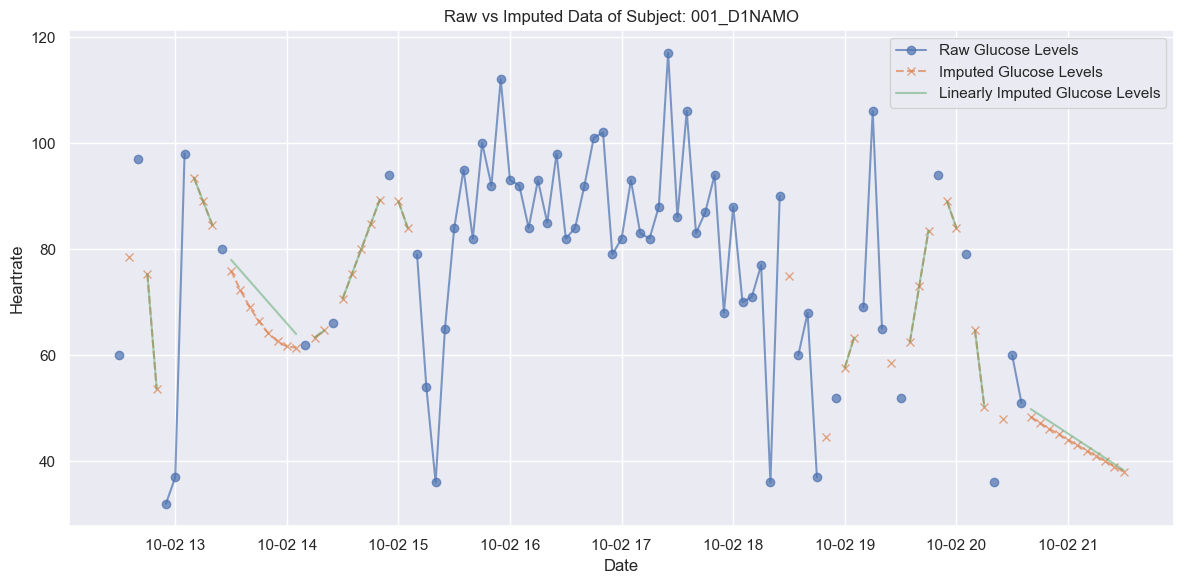

First 1-hour NaN gap starts at: 2014-10-01 12:30:00, ends at: 2014-10-01 13:50:00


/var/folders/t1/sgksm9r9385br4pts_lckj1w0000gn/T/ipykernel_3377/841181191.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  raw_week['date'] = pd.to_datetime(raw_week['ts'], format='%Y-%m-%d %H:%M:%S')


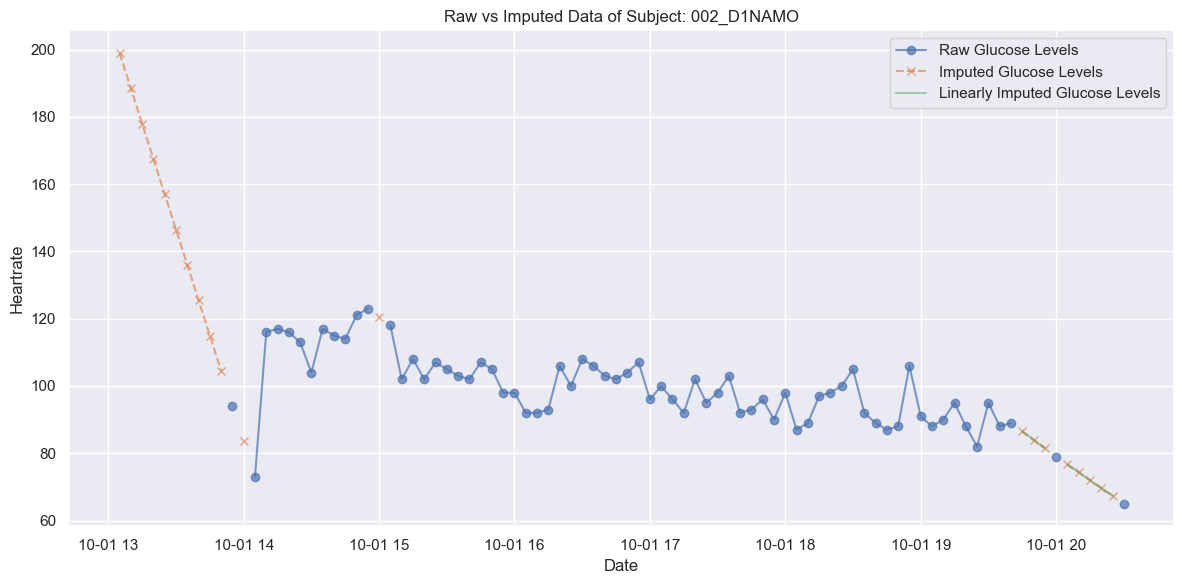

First 1-hour NaN gap starts at: 2014-10-01 10:15:00, ends at: 2014-10-01 10:45:00


/var/folders/t1/sgksm9r9385br4pts_lckj1w0000gn/T/ipykernel_3377/841181191.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  raw_week['date'] = pd.to_datetime(raw_week['ts'], format='%Y-%m-%d %H:%M:%S')


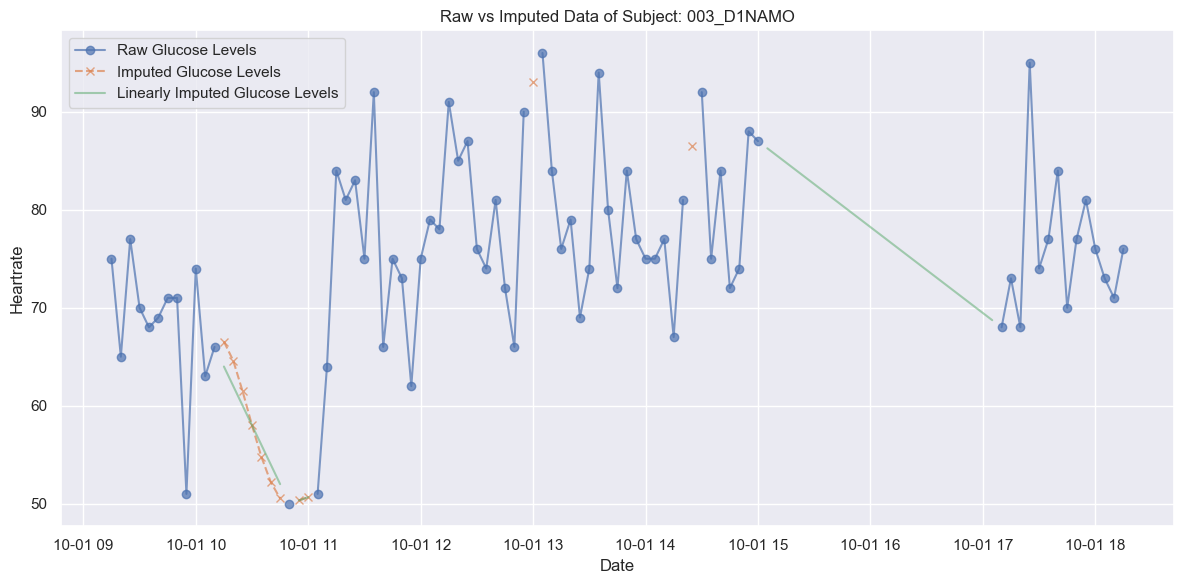

First 1-hour NaN gap starts at: 2014-10-01 14:45:00, ends at: 2014-10-01 15:10:00


/var/folders/t1/sgksm9r9385br4pts_lckj1w0000gn/T/ipykernel_3377/841181191.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  raw_week['date'] = pd.to_datetime(raw_week['ts'], format='%Y-%m-%d %H:%M:%S')


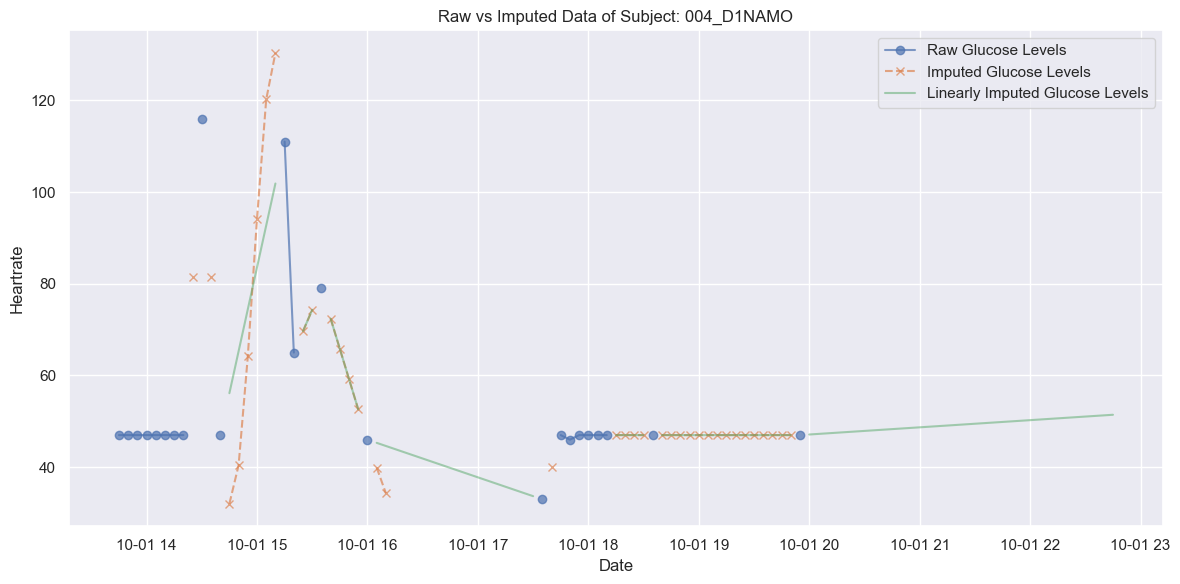

First 1-hour NaN gap starts at: 2014-10-01 12:40:00, ends at: 2014-10-01 13:45:00


/var/folders/t1/sgksm9r9385br4pts_lckj1w0000gn/T/ipykernel_3377/841181191.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  raw_week['date'] = pd.to_datetime(raw_week['ts'], format='%Y-%m-%d %H:%M:%S')


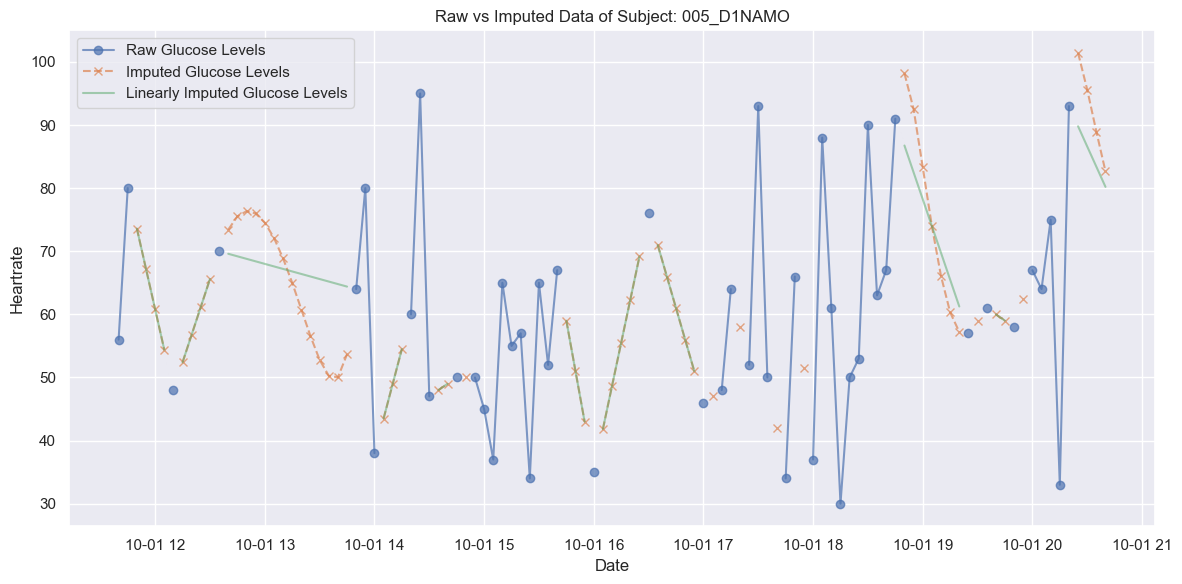

First 1-hour NaN gap starts at: 2014-10-02 00:15:00, ends at: 2014-10-02 00:50:00


/var/folders/t1/sgksm9r9385br4pts_lckj1w0000gn/T/ipykernel_3377/841181191.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  raw_week['date'] = pd.to_datetime(raw_week['ts'], format='%Y-%m-%d %H:%M:%S')


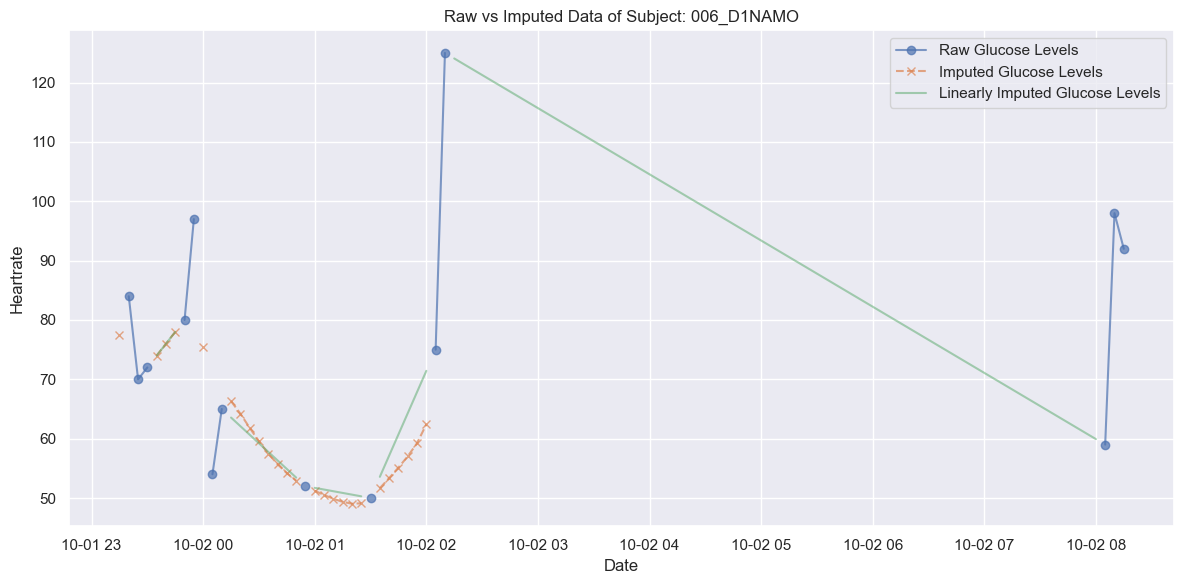

First 1-hour NaN gap starts at: 2014-10-02 09:15:00, ends at: 2014-10-02 10:20:00


/var/folders/t1/sgksm9r9385br4pts_lckj1w0000gn/T/ipykernel_3377/841181191.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  raw_week['date'] = pd.to_datetime(raw_week['ts'], format='%Y-%m-%d %H:%M:%S')


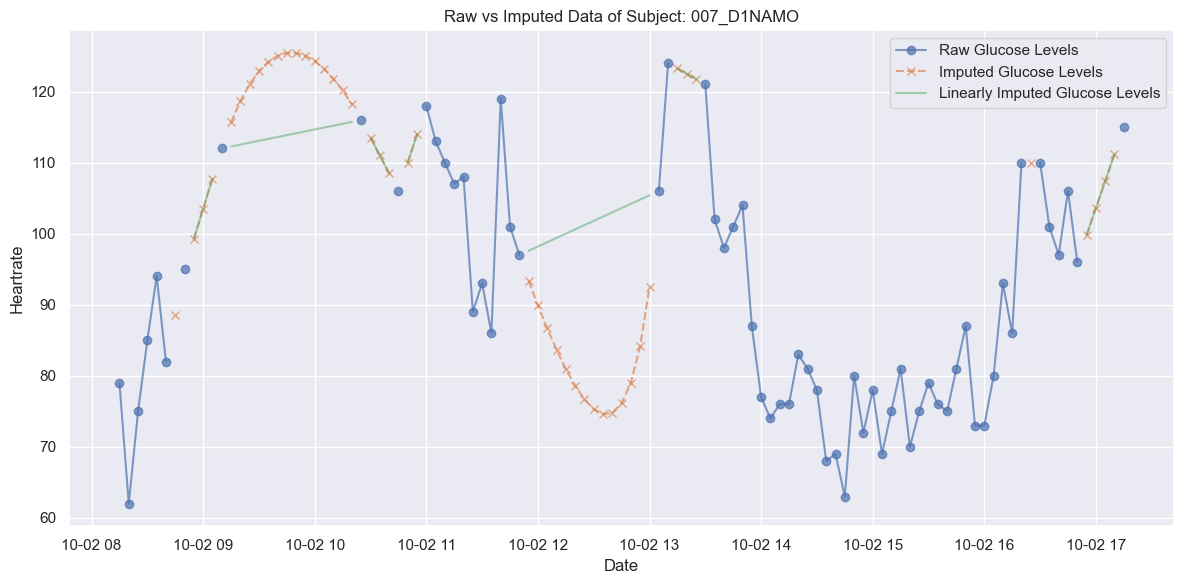

No 1-hour gap of continuous missing values found.
Non printable
First 1-hour NaN gap starts at: 2014-10-01 09:00:00, ends at: 2014-10-01 09:40:00


/var/folders/t1/sgksm9r9385br4pts_lckj1w0000gn/T/ipykernel_3377/841181191.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  raw_week['date'] = pd.to_datetime(raw_week['ts'], format='%Y-%m-%d %H:%M:%S')


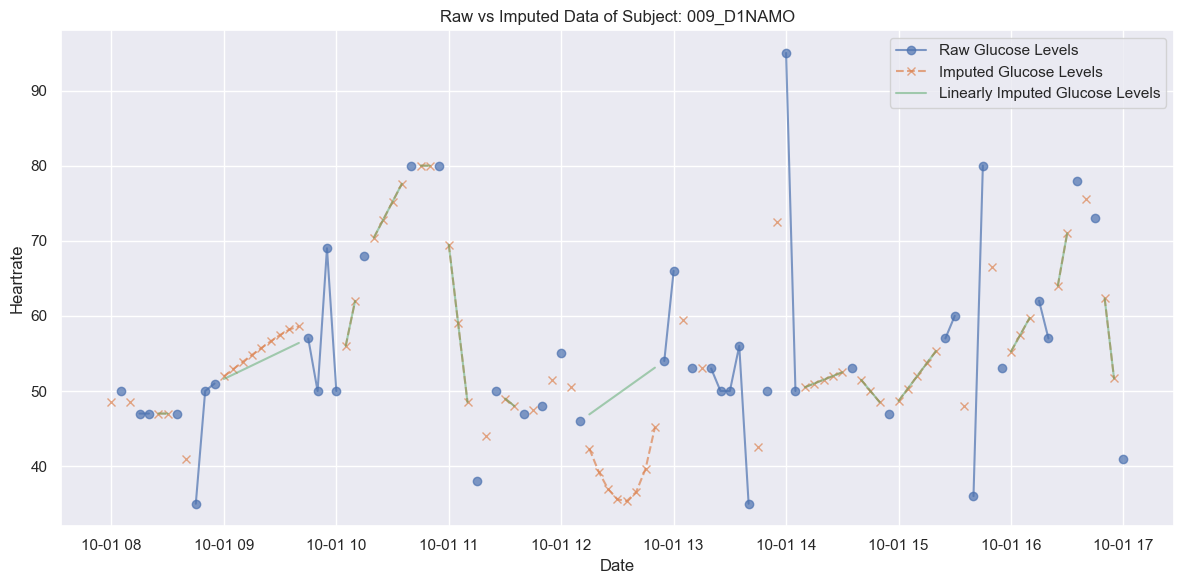

First 1-hour NaN gap starts at: 2019-10-23 10:40:00, ends at: 2019-10-23 11:50:00


/var/folders/t1/sgksm9r9385br4pts_lckj1w0000gn/T/ipykernel_3377/841181191.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  raw_week['date'] = pd.to_datetime(raw_week['ts'], format='%Y-%m-%d %H:%M:%S')


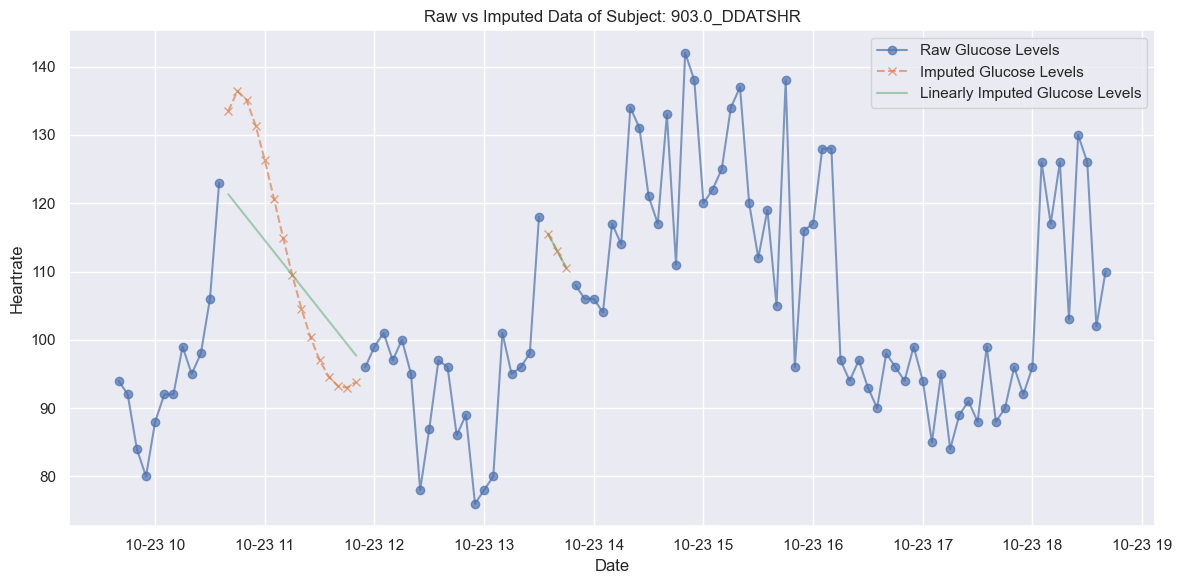

First 1-hour NaN gap starts at: 2019-10-15 07:40:00, ends at: 2019-10-15 08:05:00


/var/folders/t1/sgksm9r9385br4pts_lckj1w0000gn/T/ipykernel_3377/841181191.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  raw_week['date'] = pd.to_datetime(raw_week['ts'], format='%Y-%m-%d %H:%M:%S')


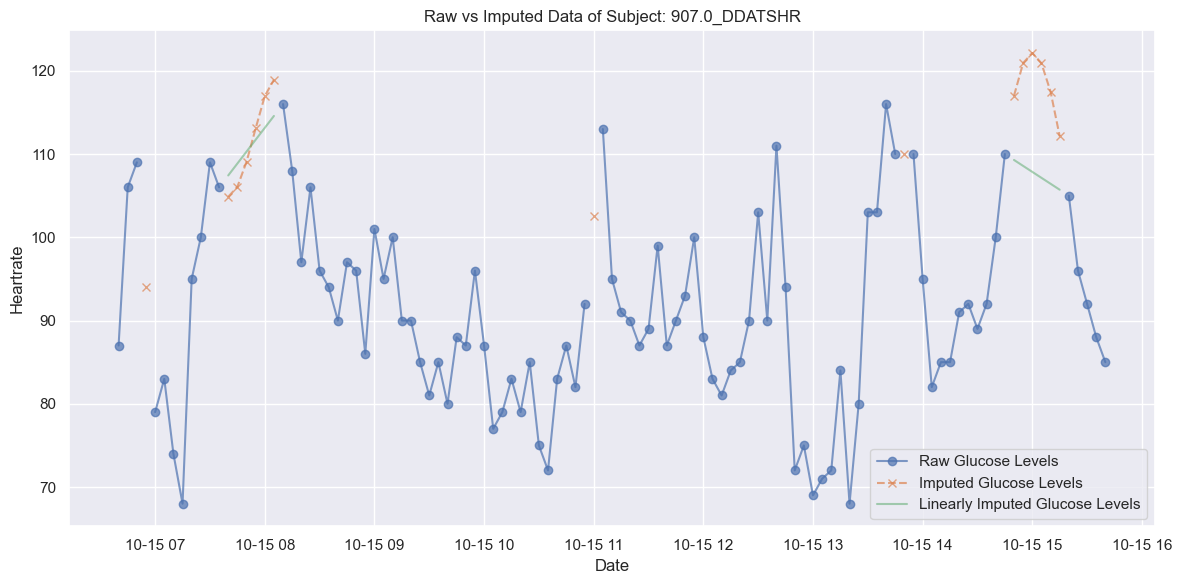

First 1-hour NaN gap starts at: 2019-10-26 04:55:00, ends at: 2019-10-26 05:25:00


/var/folders/t1/sgksm9r9385br4pts_lckj1w0000gn/T/ipykernel_3377/841181191.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  raw_week['date'] = pd.to_datetime(raw_week['ts'], format='%Y-%m-%d %H:%M:%S')


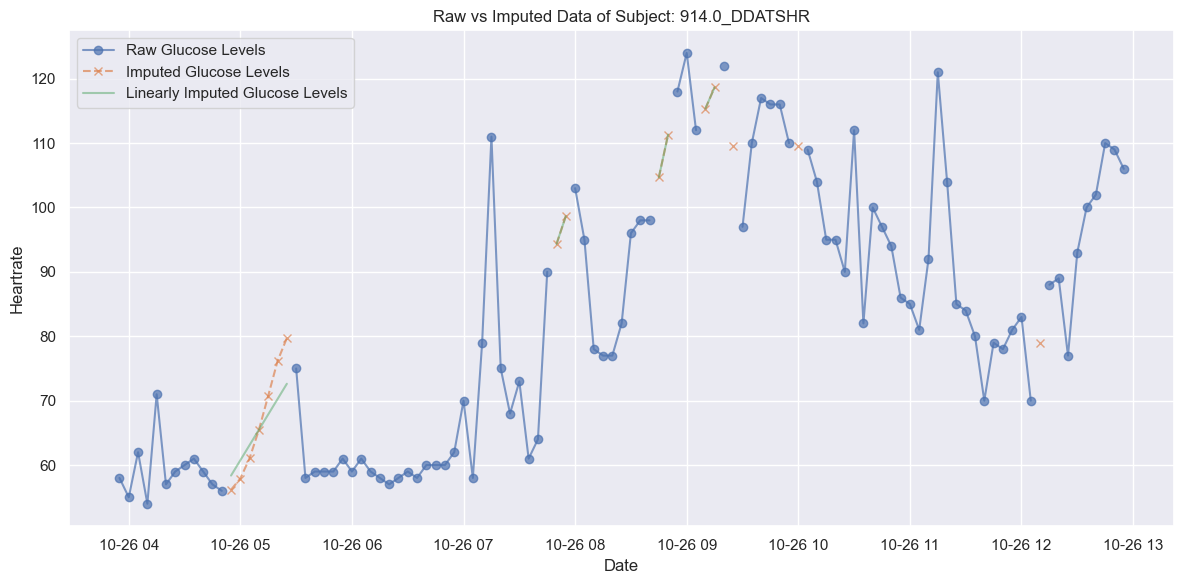

First 1-hour NaN gap starts at: 2019-10-15 19:45:00, ends at: 2019-10-15 20:35:00


/var/folders/t1/sgksm9r9385br4pts_lckj1w0000gn/T/ipykernel_3377/841181191.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  raw_week['date'] = pd.to_datetime(raw_week['ts'], format='%Y-%m-%d %H:%M:%S')


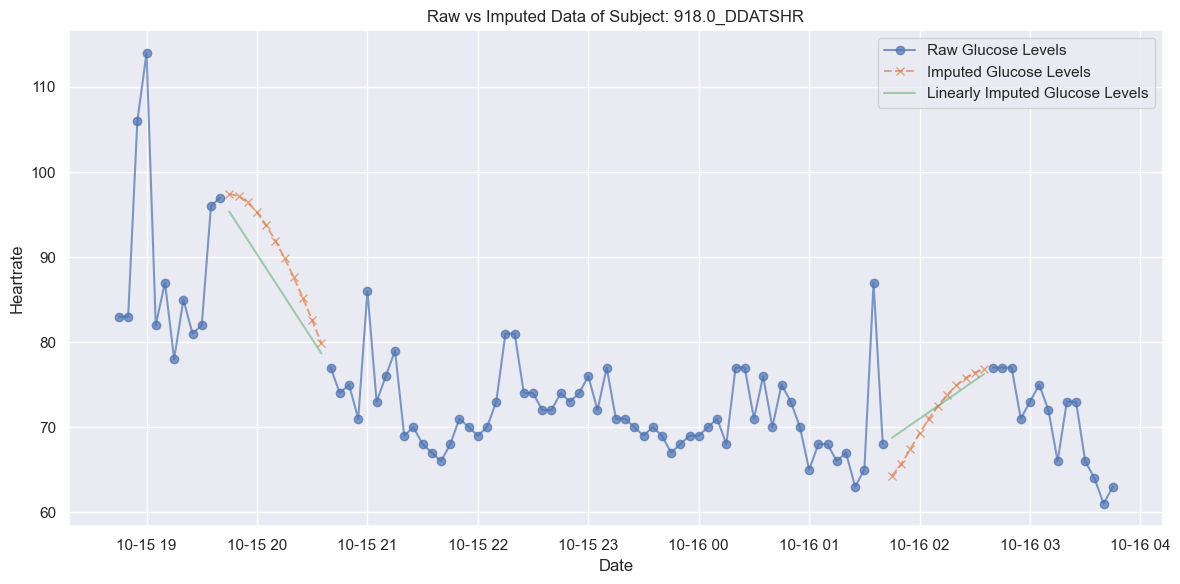

First 1-hour NaN gap starts at: 2019-10-15 10:35:00, ends at: 2019-10-15 11:20:00


/var/folders/t1/sgksm9r9385br4pts_lckj1w0000gn/T/ipykernel_3377/841181191.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  raw_week['date'] = pd.to_datetime(raw_week['ts'], format='%Y-%m-%d %H:%M:%S')


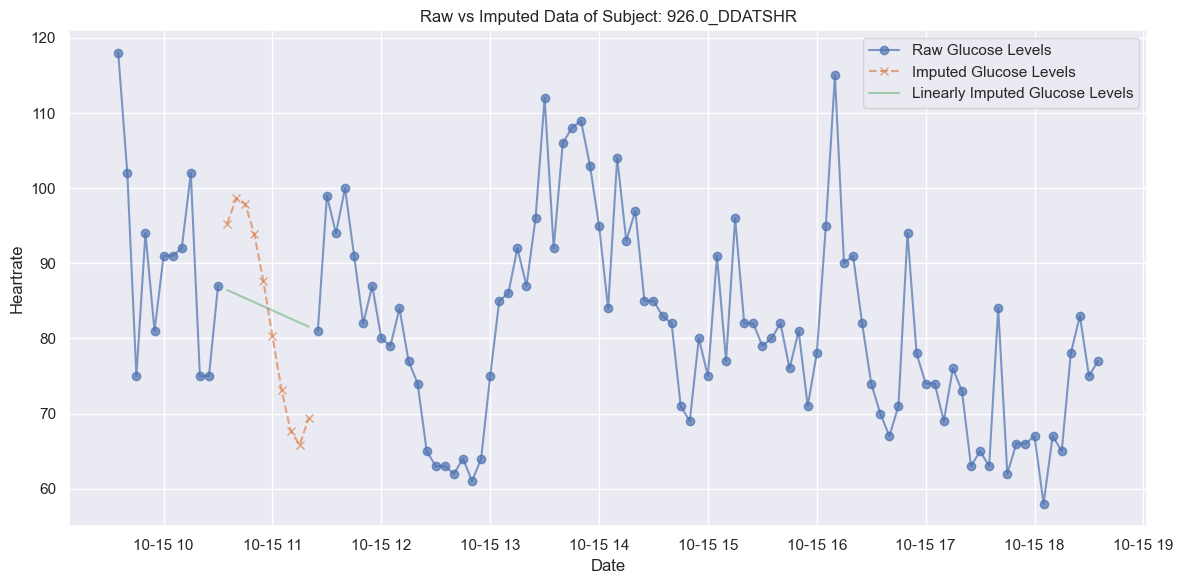

First 1-hour NaN gap starts at: 2019-10-16 04:35:00, ends at: 2019-10-16 06:05:00


/var/folders/t1/sgksm9r9385br4pts_lckj1w0000gn/T/ipykernel_3377/841181191.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  raw_week['date'] = pd.to_datetime(raw_week['ts'], format='%Y-%m-%d %H:%M:%S')


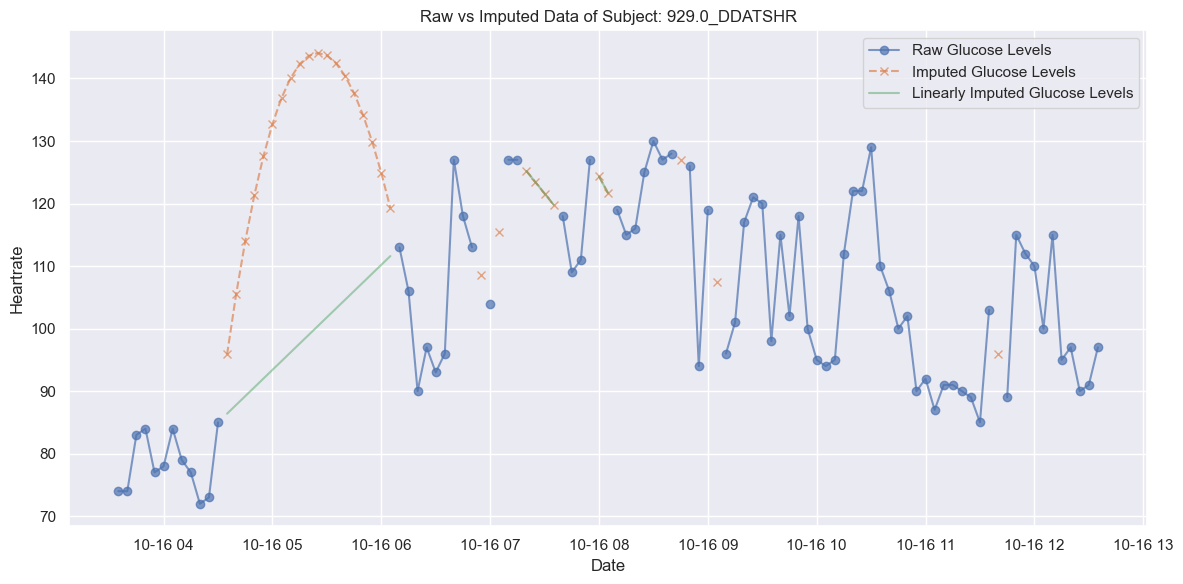

First 1-hour NaN gap starts at: 2019-10-15 19:35:00, ends at: 2019-10-15 20:35:00


/var/folders/t1/sgksm9r9385br4pts_lckj1w0000gn/T/ipykernel_3377/841181191.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  raw_week['date'] = pd.to_datetime(raw_week['ts'], format='%Y-%m-%d %H:%M:%S')


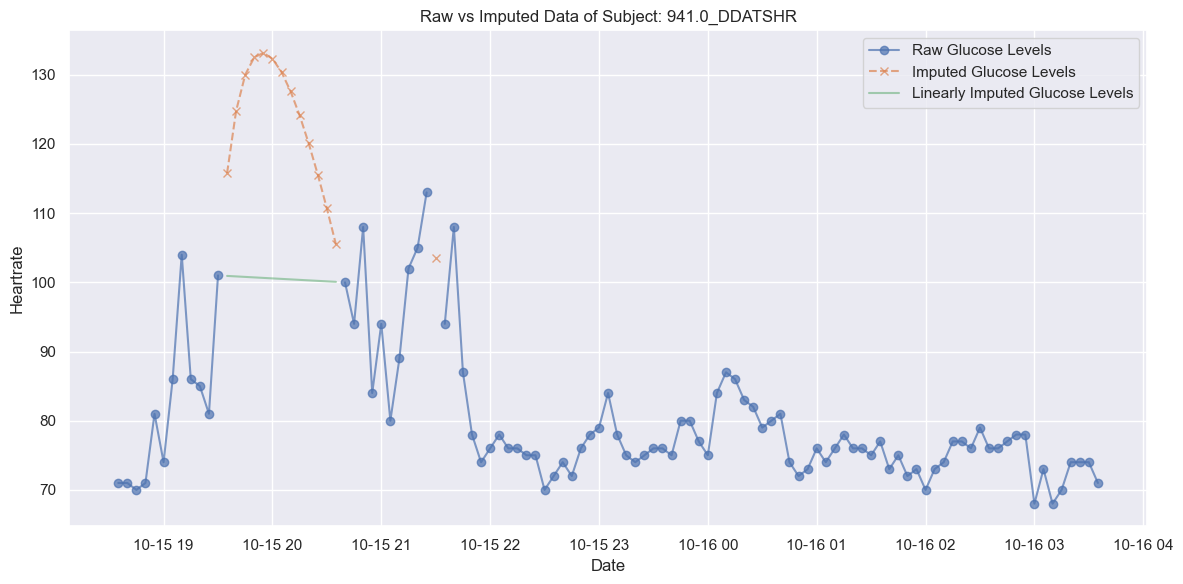

First 1-hour NaN gap starts at: 2019-10-19 01:10:00, ends at: 2019-10-19 01:55:00


/var/folders/t1/sgksm9r9385br4pts_lckj1w0000gn/T/ipykernel_3377/841181191.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  raw_week['date'] = pd.to_datetime(raw_week['ts'], format='%Y-%m-%d %H:%M:%S')


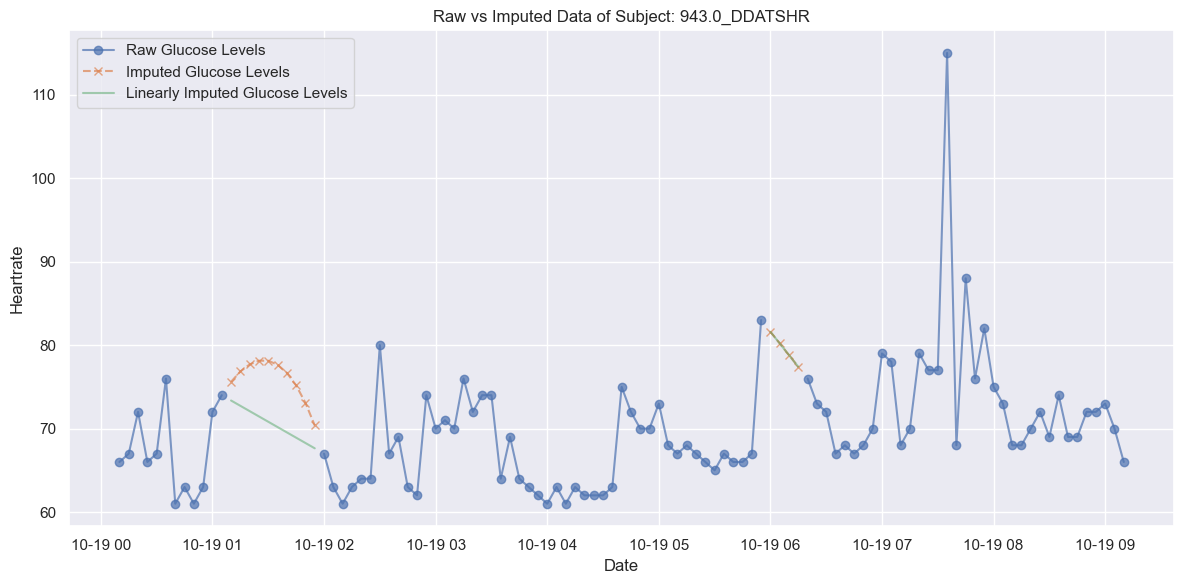

First 1-hour NaN gap starts at: 2019-10-15 16:45:00, ends at: 2019-10-15 17:15:00


/var/folders/t1/sgksm9r9385br4pts_lckj1w0000gn/T/ipykernel_3377/841181191.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  raw_week['date'] = pd.to_datetime(raw_week['ts'], format='%Y-%m-%d %H:%M:%S')


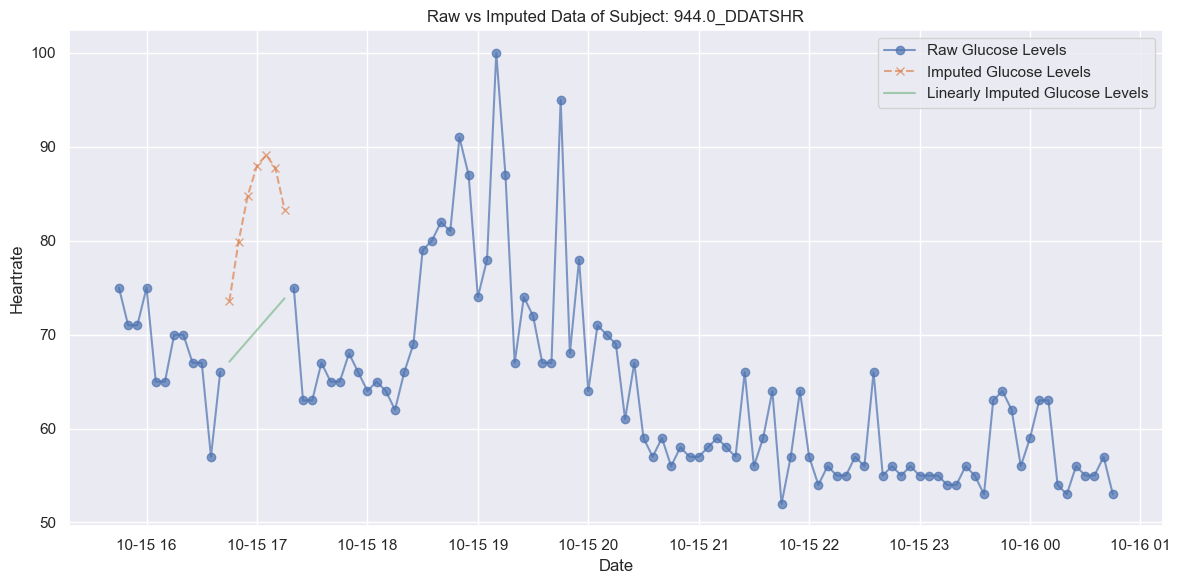

First 1-hour NaN gap starts at: 2019-10-15 19:00:00, ends at: 2019-10-15 19:45:00


/var/folders/t1/sgksm9r9385br4pts_lckj1w0000gn/T/ipykernel_3377/841181191.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  raw_week['date'] = pd.to_datetime(raw_week['ts'], format='%Y-%m-%d %H:%M:%S')


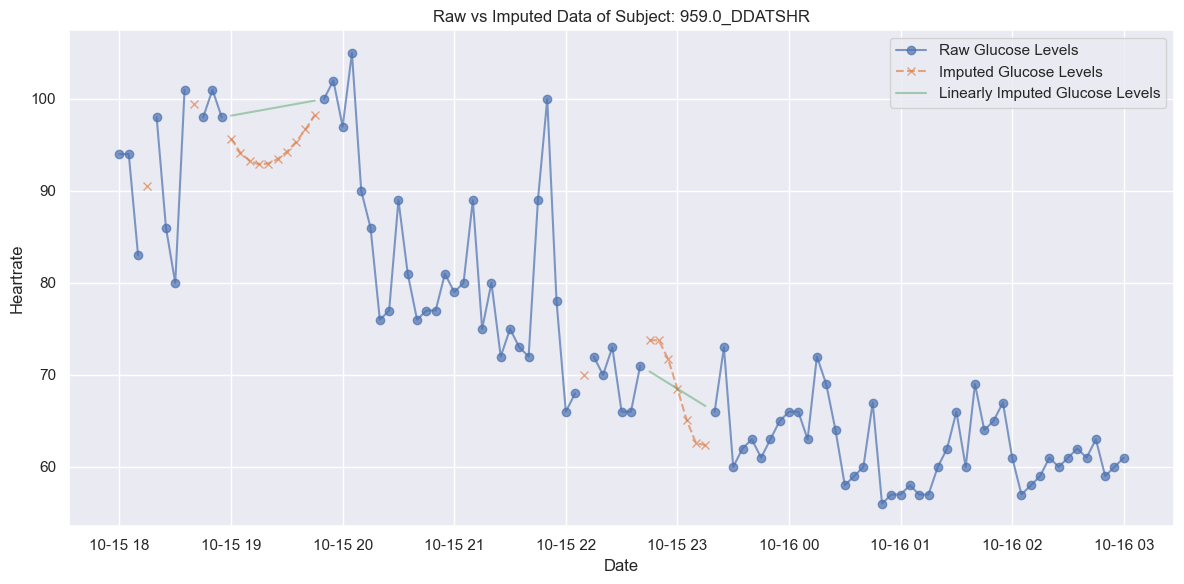

First 1-hour NaN gap starts at: 2019-10-16 13:55:00, ends at: 2019-10-16 14:20:00


/var/folders/t1/sgksm9r9385br4pts_lckj1w0000gn/T/ipykernel_3377/841181191.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  raw_week['date'] = pd.to_datetime(raw_week['ts'], format='%Y-%m-%d %H:%M:%S')


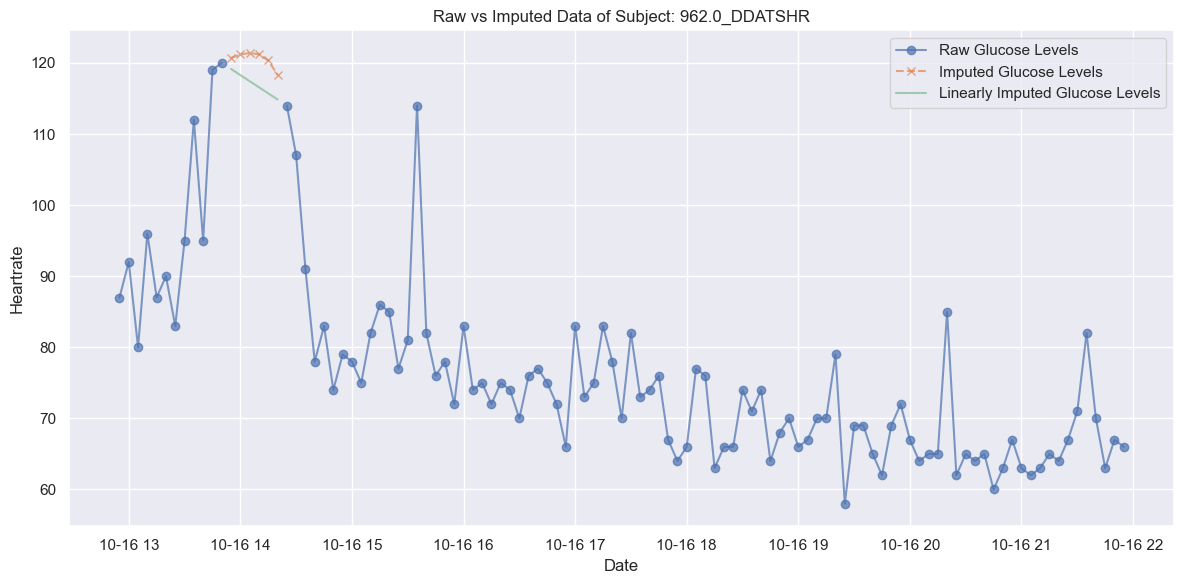

First 1-hour NaN gap starts at: 2019-10-15 18:20:00, ends at: 2019-10-15 19:00:00


/var/folders/t1/sgksm9r9385br4pts_lckj1w0000gn/T/ipykernel_3377/841181191.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  raw_week['date'] = pd.to_datetime(raw_week['ts'], format='%Y-%m-%d %H:%M:%S')


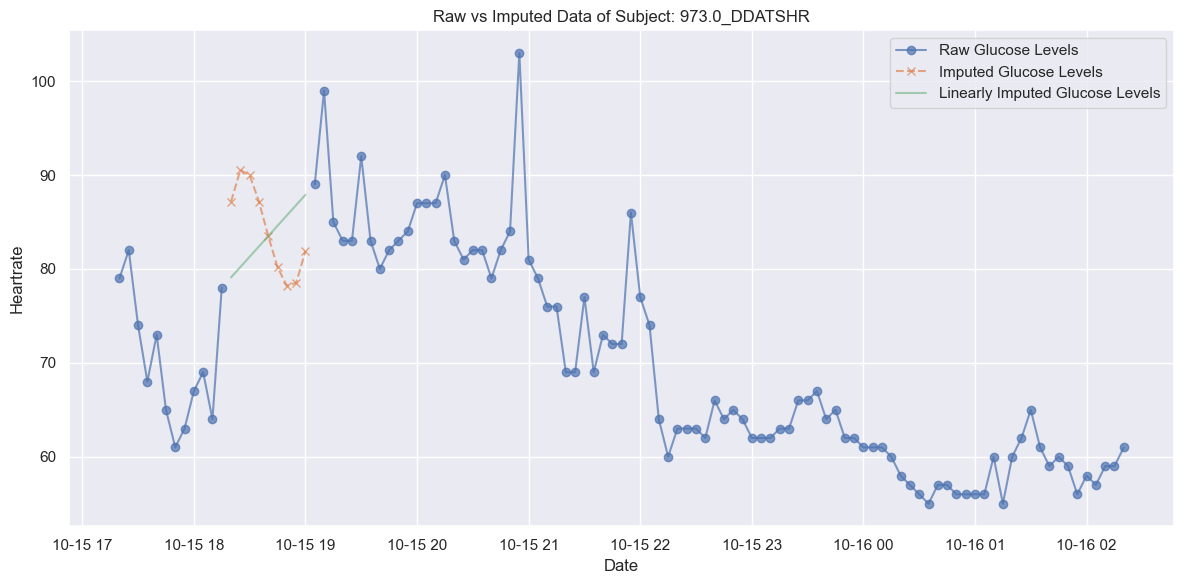

First 1-hour NaN gap starts at: 2019-10-24 09:55:00, ends at: 2019-10-24 11:40:00


/var/folders/t1/sgksm9r9385br4pts_lckj1w0000gn/T/ipykernel_3377/841181191.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  raw_week['date'] = pd.to_datetime(raw_week['ts'], format='%Y-%m-%d %H:%M:%S')


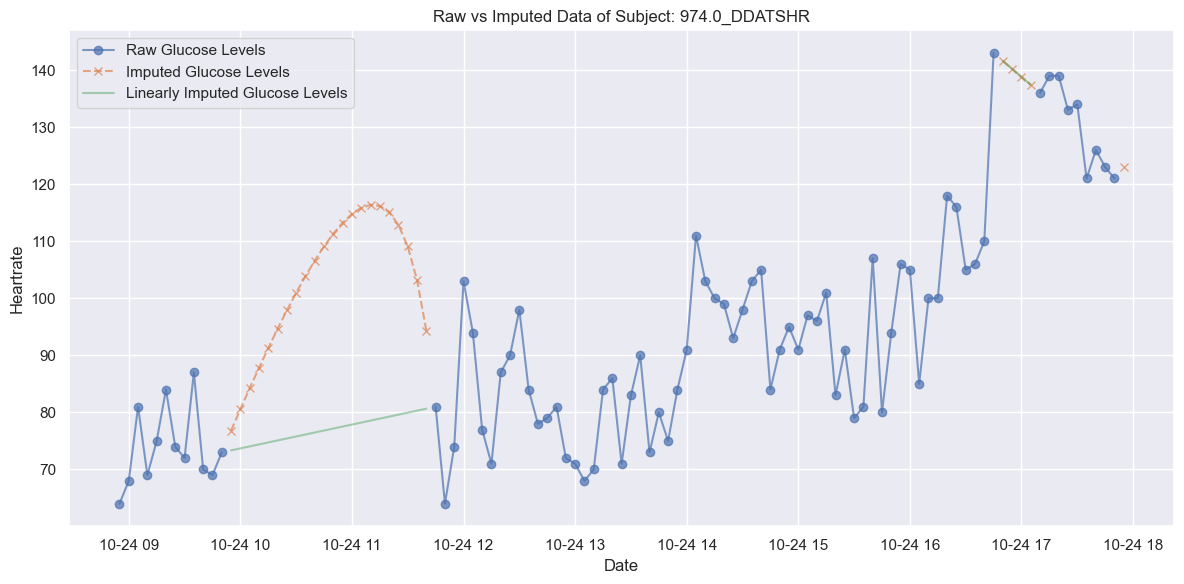

First 1-hour NaN gap starts at: 2019-10-22 05:30:00, ends at: 2019-10-22 06:10:00


/var/folders/t1/sgksm9r9385br4pts_lckj1w0000gn/T/ipykernel_3377/841181191.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  raw_week['date'] = pd.to_datetime(raw_week['ts'], format='%Y-%m-%d %H:%M:%S')


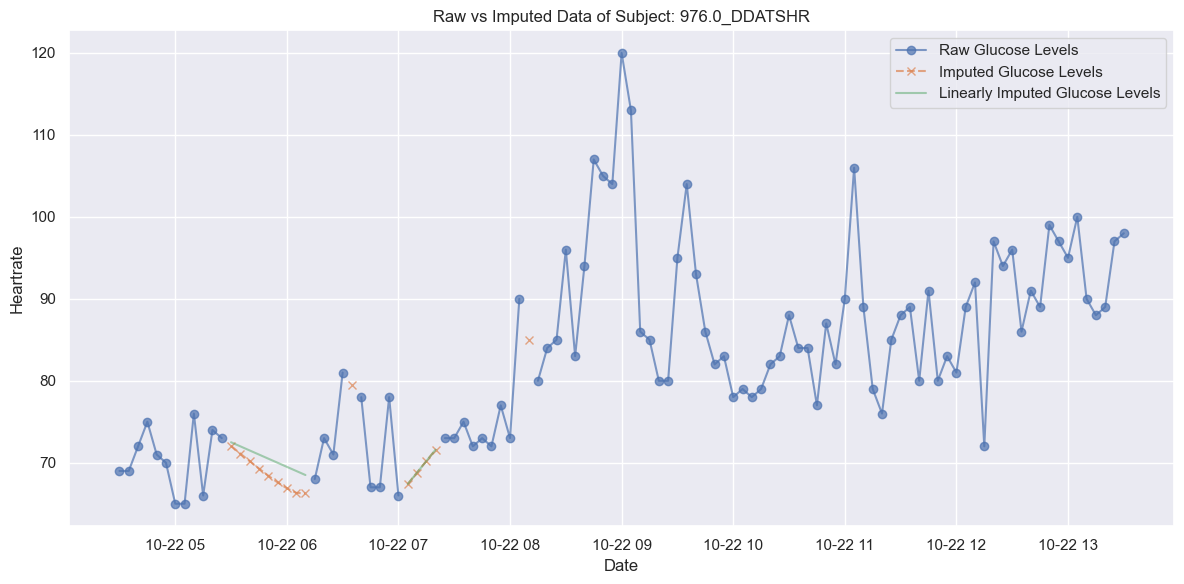

First 1-hour NaN gap starts at: 2019-10-16 18:40:00, ends at: 2019-10-16 20:15:00


/var/folders/t1/sgksm9r9385br4pts_lckj1w0000gn/T/ipykernel_3377/841181191.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  raw_week['date'] = pd.to_datetime(raw_week['ts'], format='%Y-%m-%d %H:%M:%S')


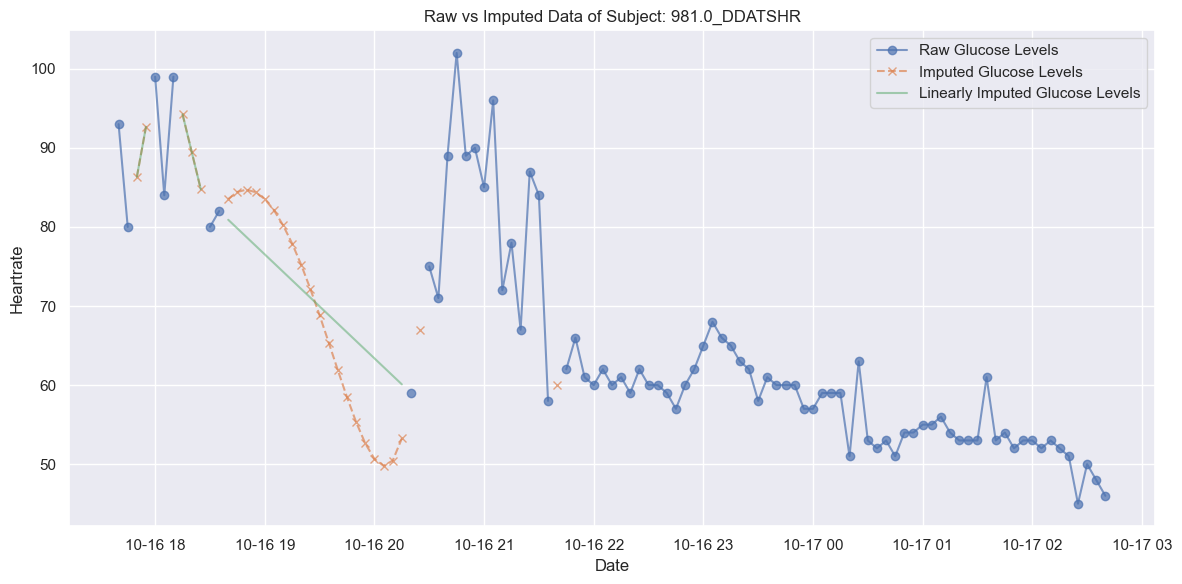

First 1-hour NaN gap starts at: 2019-10-20 12:25:00, ends at: 2019-10-20 12:55:00


/var/folders/t1/sgksm9r9385br4pts_lckj1w0000gn/T/ipykernel_3377/841181191.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  raw_week['date'] = pd.to_datetime(raw_week['ts'], format='%Y-%m-%d %H:%M:%S')


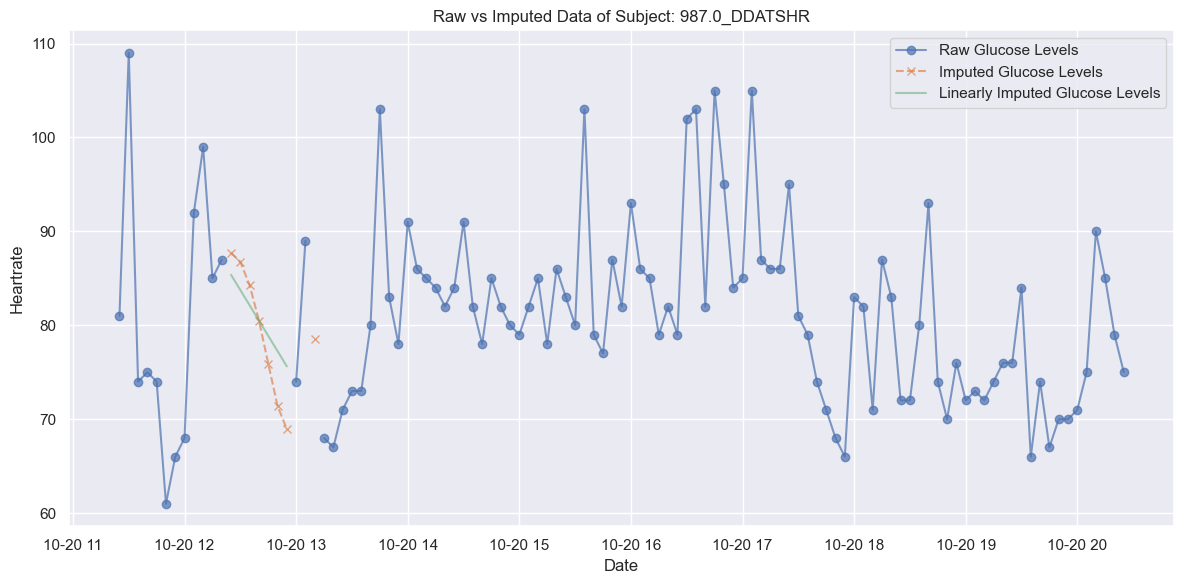

First 1-hour NaN gap starts at: 2019-11-04 06:45:00, ends at: 2019-11-04 07:10:00


/var/folders/t1/sgksm9r9385br4pts_lckj1w0000gn/T/ipykernel_3377/841181191.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  raw_week['date'] = pd.to_datetime(raw_week['ts'], format='%Y-%m-%d %H:%M:%S')


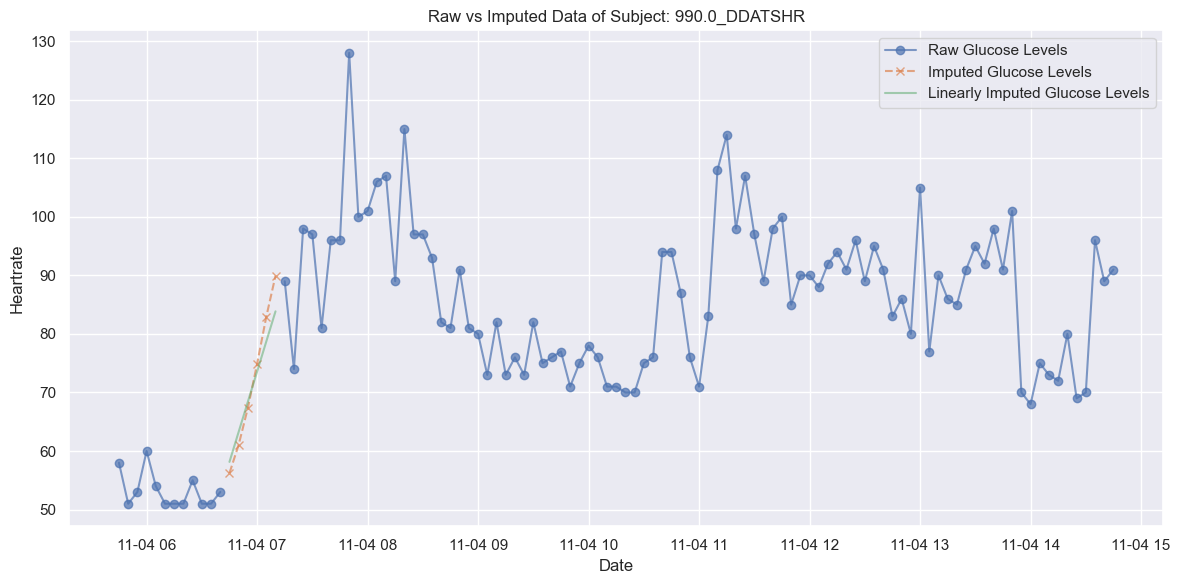

First 1-hour NaN gap starts at: 2019-10-19 19:50:00, ends at: 2019-10-19 20:30:00


/var/folders/t1/sgksm9r9385br4pts_lckj1w0000gn/T/ipykernel_3377/841181191.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  raw_week['date'] = pd.to_datetime(raw_week['ts'], format='%Y-%m-%d %H:%M:%S')


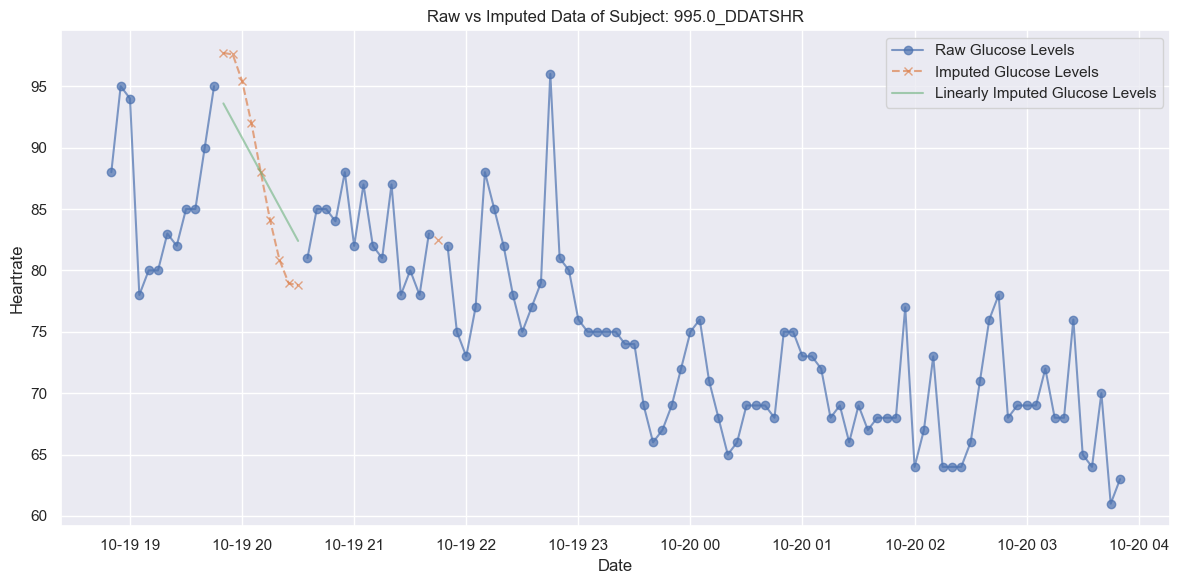

First 1-hour NaN gap starts at: 2018-06-13 17:20:00, ends at: 2018-06-13 18:35:00


/var/folders/t1/sgksm9r9385br4pts_lckj1w0000gn/T/ipykernel_3377/841181191.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  raw_week['date'] = pd.to_datetime(raw_week['ts'], format='%Y-%m-%d %H:%M:%S')


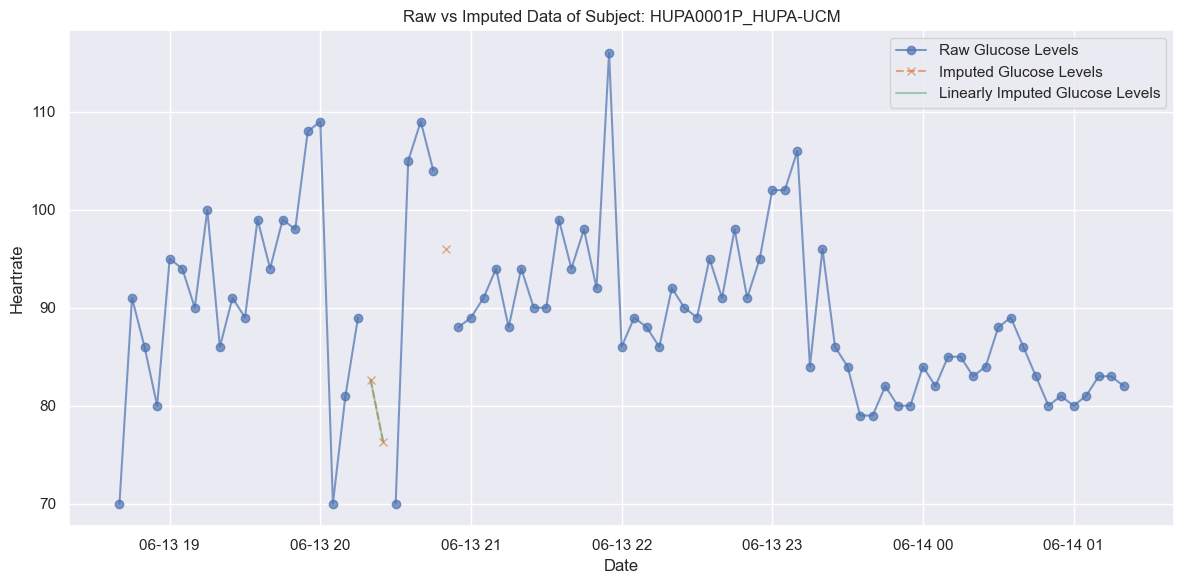

First 1-hour NaN gap starts at: 2018-06-14 21:40:00, ends at: 2018-06-14 22:55:00


/var/folders/t1/sgksm9r9385br4pts_lckj1w0000gn/T/ipykernel_3377/841181191.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  raw_week['date'] = pd.to_datetime(raw_week['ts'], format='%Y-%m-%d %H:%M:%S')


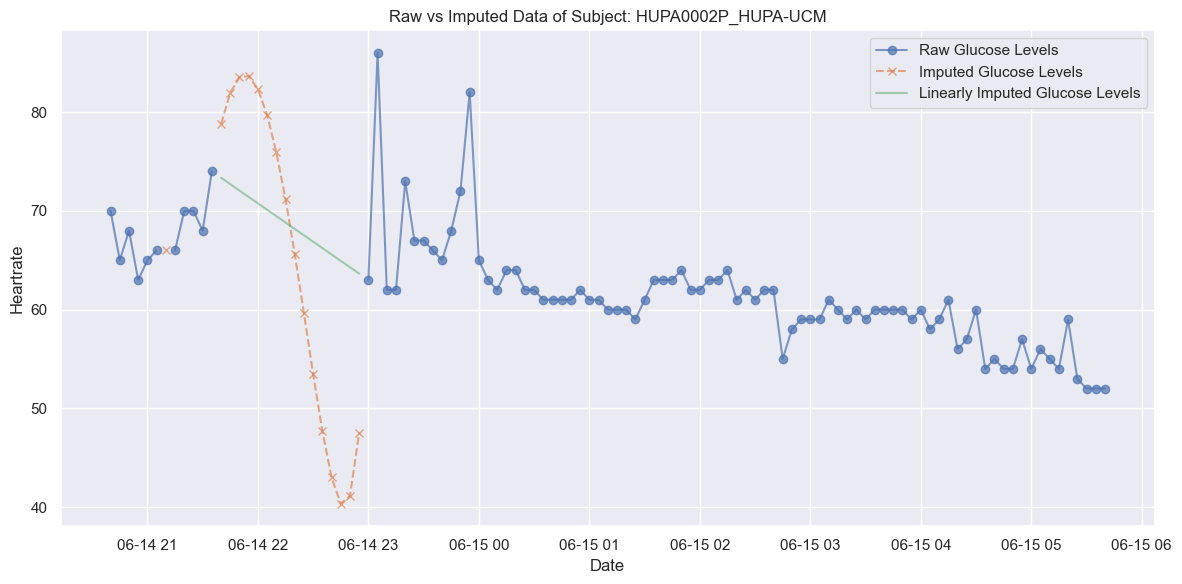

First 1-hour NaN gap starts at: 2018-06-21 18:20:00, ends at: 2018-06-21 18:55:00


/var/folders/t1/sgksm9r9385br4pts_lckj1w0000gn/T/ipykernel_3377/841181191.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  raw_week['date'] = pd.to_datetime(raw_week['ts'], format='%Y-%m-%d %H:%M:%S')


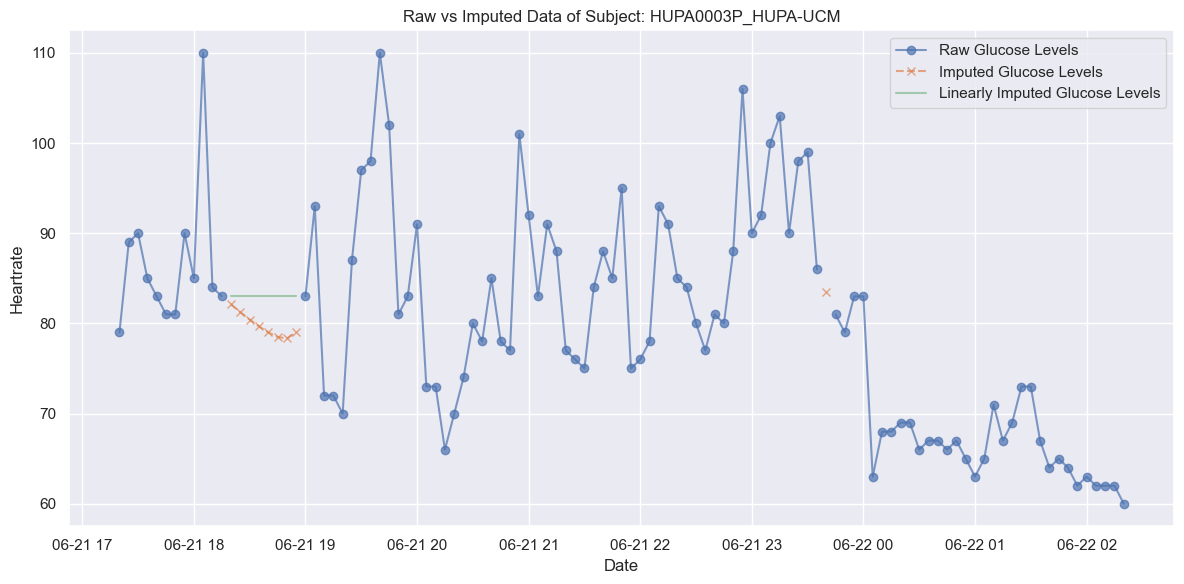

First 1-hour NaN gap starts at: 2018-07-12 01:05:00, ends at: 2018-07-12 01:40:00


/var/folders/t1/sgksm9r9385br4pts_lckj1w0000gn/T/ipykernel_3377/841181191.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  raw_week['date'] = pd.to_datetime(raw_week['ts'], format='%Y-%m-%d %H:%M:%S')


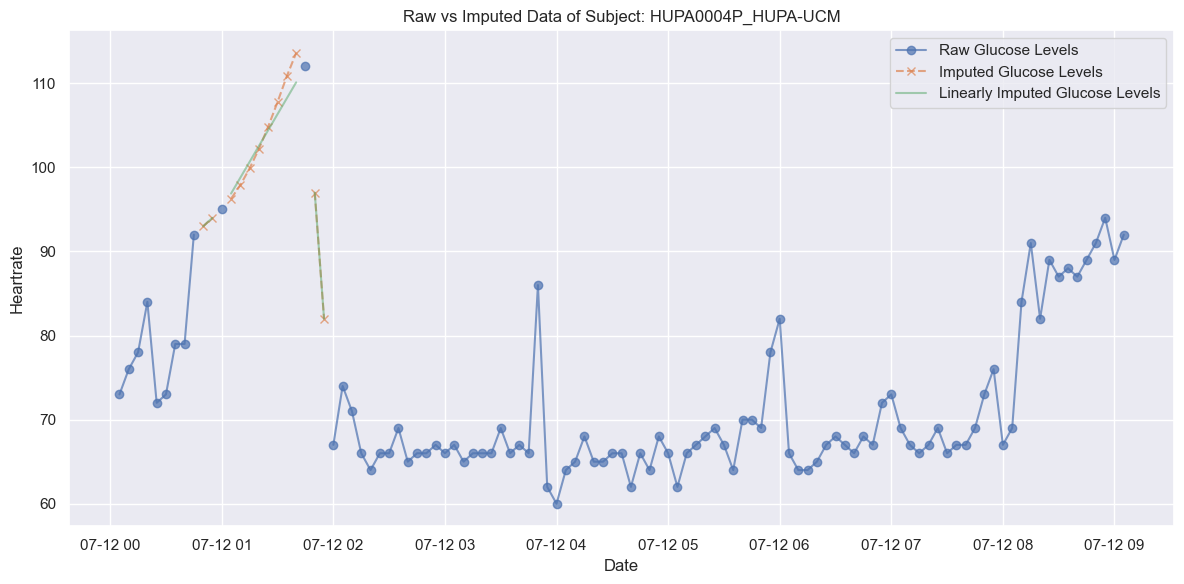

First 1-hour NaN gap starts at: 2018-07-10 12:20:00, ends at: 2018-07-10 13:00:00


/var/folders/t1/sgksm9r9385br4pts_lckj1w0000gn/T/ipykernel_3377/841181191.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  raw_week['date'] = pd.to_datetime(raw_week['ts'], format='%Y-%m-%d %H:%M:%S')


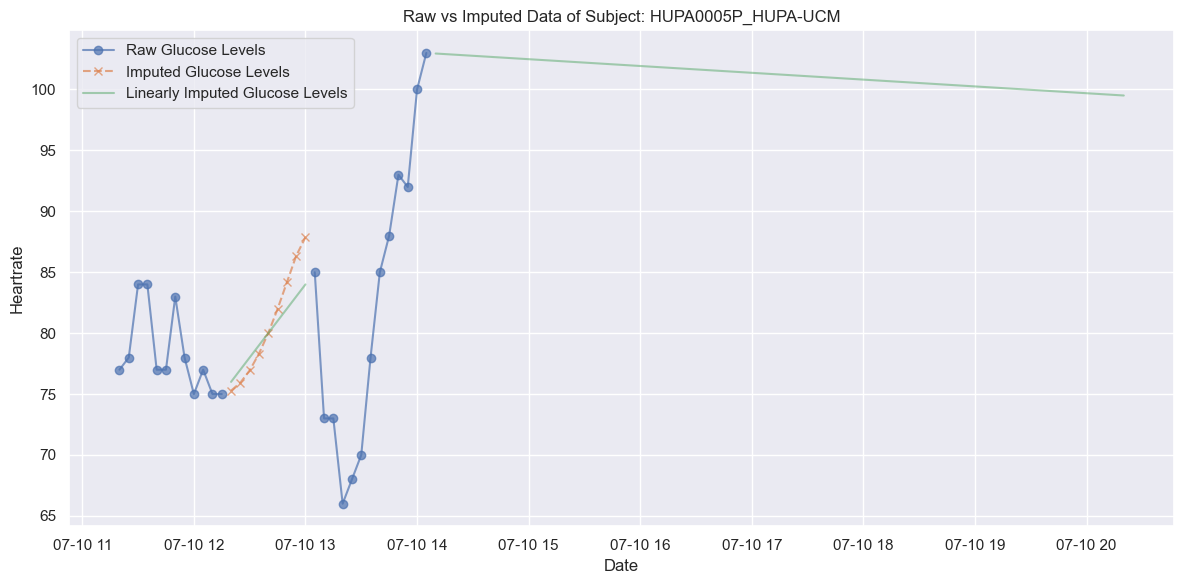

First 1-hour NaN gap starts at: 2018-07-14 18:45:00, ends at: 2018-07-14 19:25:00


/var/folders/t1/sgksm9r9385br4pts_lckj1w0000gn/T/ipykernel_3377/841181191.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  raw_week['date'] = pd.to_datetime(raw_week['ts'], format='%Y-%m-%d %H:%M:%S')


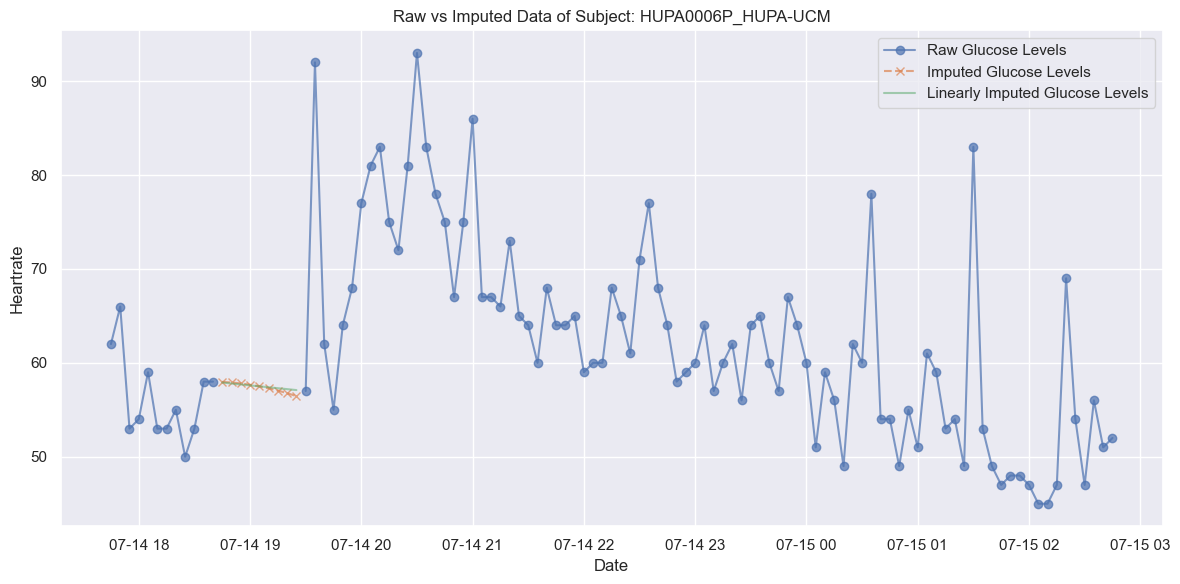

First 1-hour NaN gap starts at: 2018-09-19 22:10:00, ends at: 2018-09-19 22:35:00


/var/folders/t1/sgksm9r9385br4pts_lckj1w0000gn/T/ipykernel_3377/841181191.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  raw_week['date'] = pd.to_datetime(raw_week['ts'], format='%Y-%m-%d %H:%M:%S')


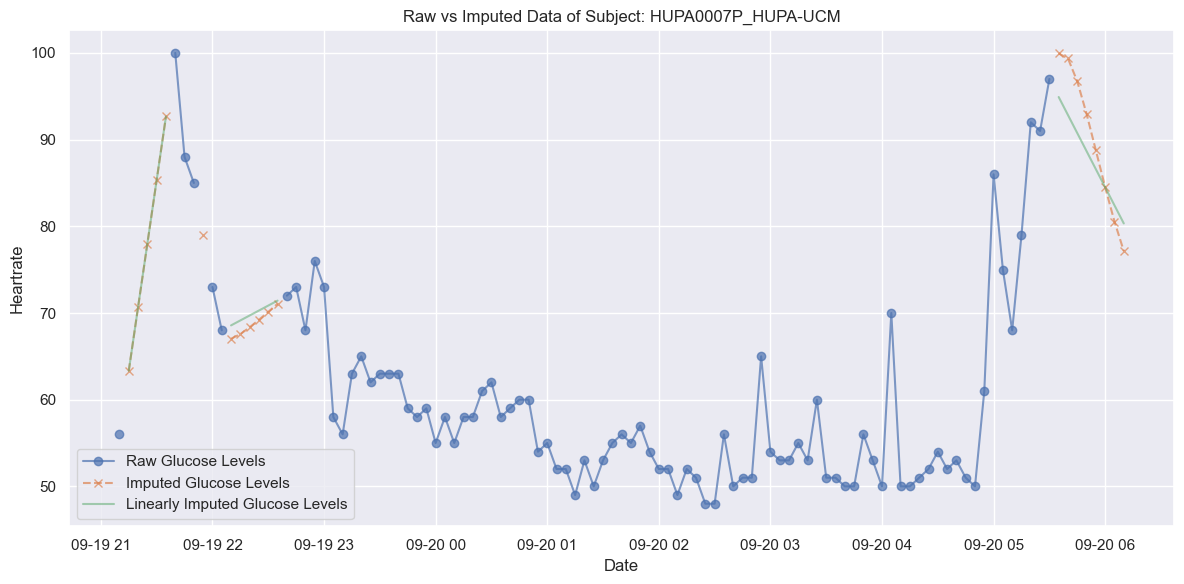

First 1-hour NaN gap starts at: 2018-11-08 07:35:00, ends at: 2018-11-08 08:00:00


/var/folders/t1/sgksm9r9385br4pts_lckj1w0000gn/T/ipykernel_3377/841181191.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  raw_week['date'] = pd.to_datetime(raw_week['ts'], format='%Y-%m-%d %H:%M:%S')


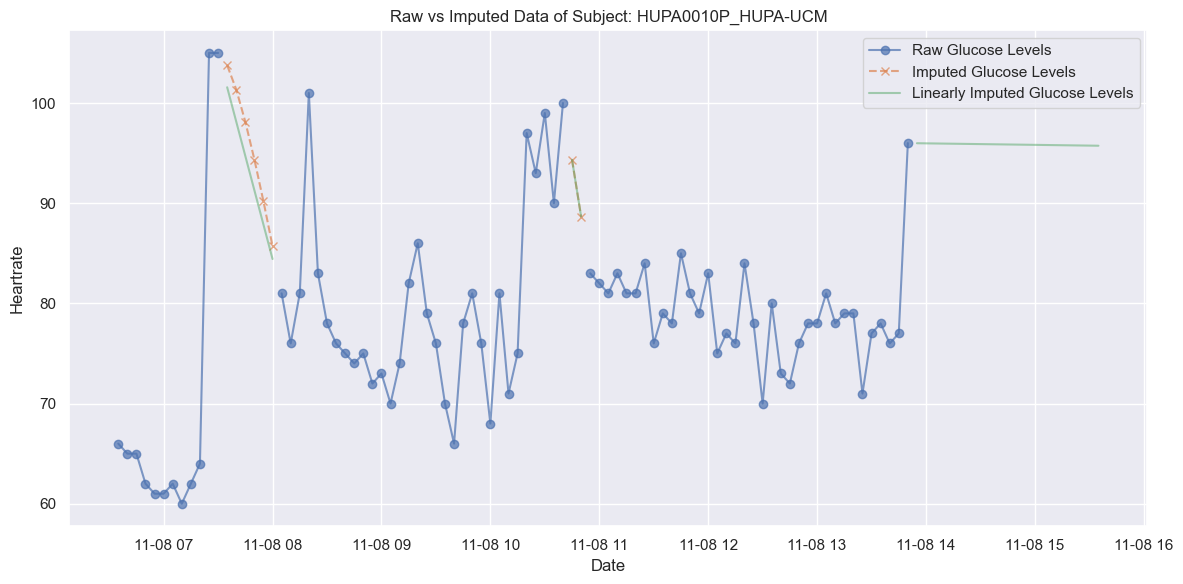

First 1-hour NaN gap starts at: 2018-11-08 09:35:00, ends at: 2018-11-08 10:20:00


/var/folders/t1/sgksm9r9385br4pts_lckj1w0000gn/T/ipykernel_3377/841181191.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  raw_week['date'] = pd.to_datetime(raw_week['ts'], format='%Y-%m-%d %H:%M:%S')


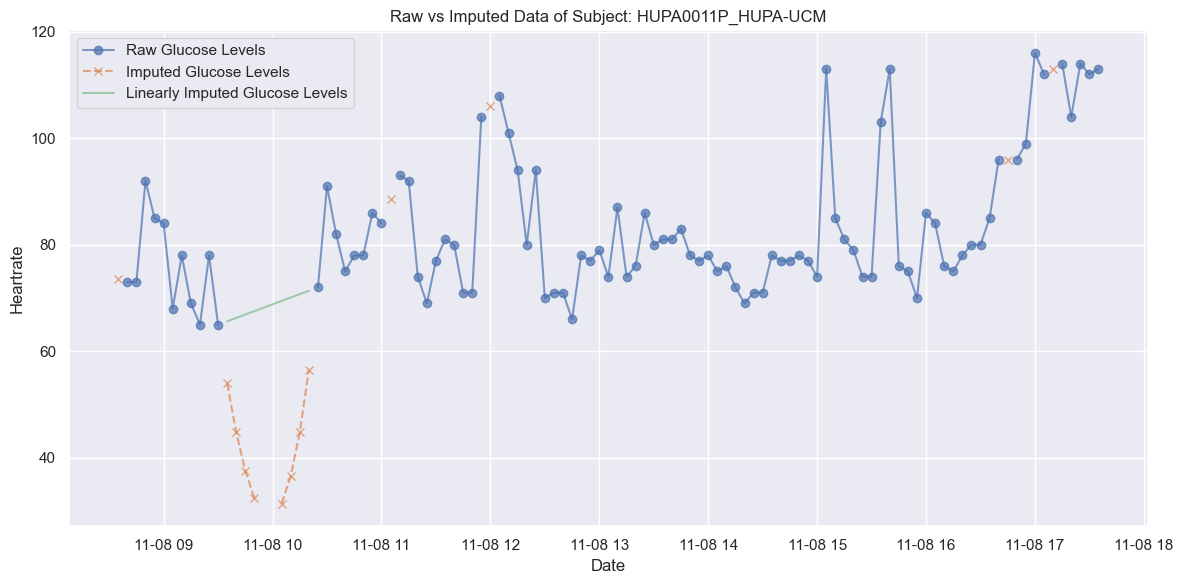

First 1-hour NaN gap starts at: 2018-11-09 16:55:00, ends at: 2018-11-09 18:20:00


/var/folders/t1/sgksm9r9385br4pts_lckj1w0000gn/T/ipykernel_3377/841181191.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  raw_week['date'] = pd.to_datetime(raw_week['ts'], format='%Y-%m-%d %H:%M:%S')


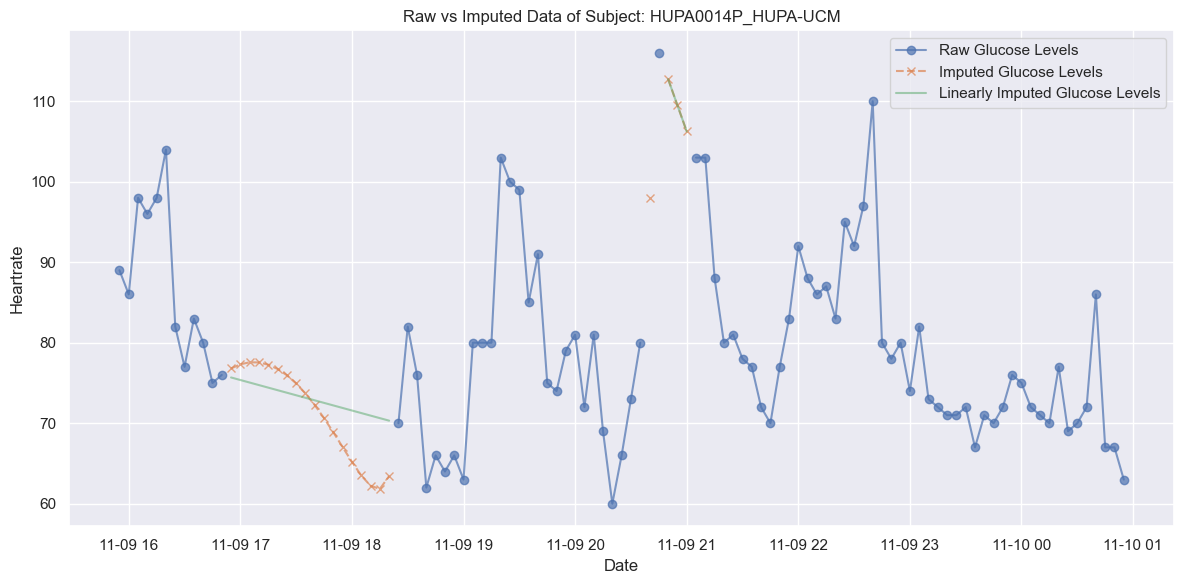

First 1-hour NaN gap starts at: 2019-03-27 19:25:00, ends at: 2019-03-27 20:00:00


/var/folders/t1/sgksm9r9385br4pts_lckj1w0000gn/T/ipykernel_3377/841181191.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  raw_week['date'] = pd.to_datetime(raw_week['ts'], format='%Y-%m-%d %H:%M:%S')


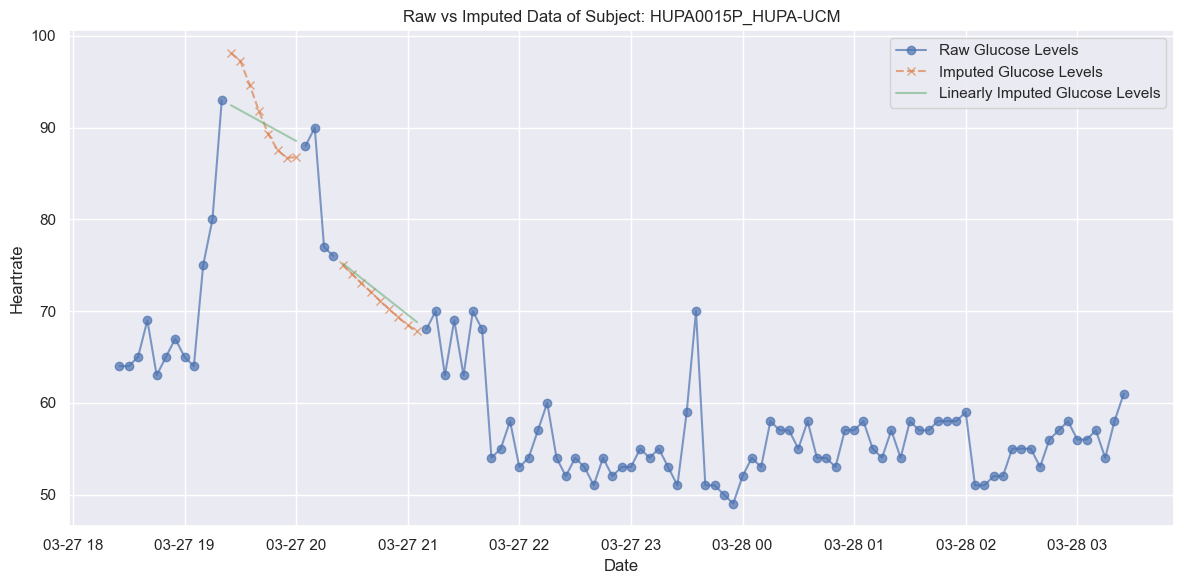

First 1-hour NaN gap starts at: 2019-03-27 19:55:00, ends at: 2019-03-27 21:00:00


/var/folders/t1/sgksm9r9385br4pts_lckj1w0000gn/T/ipykernel_3377/841181191.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  raw_week['date'] = pd.to_datetime(raw_week['ts'], format='%Y-%m-%d %H:%M:%S')


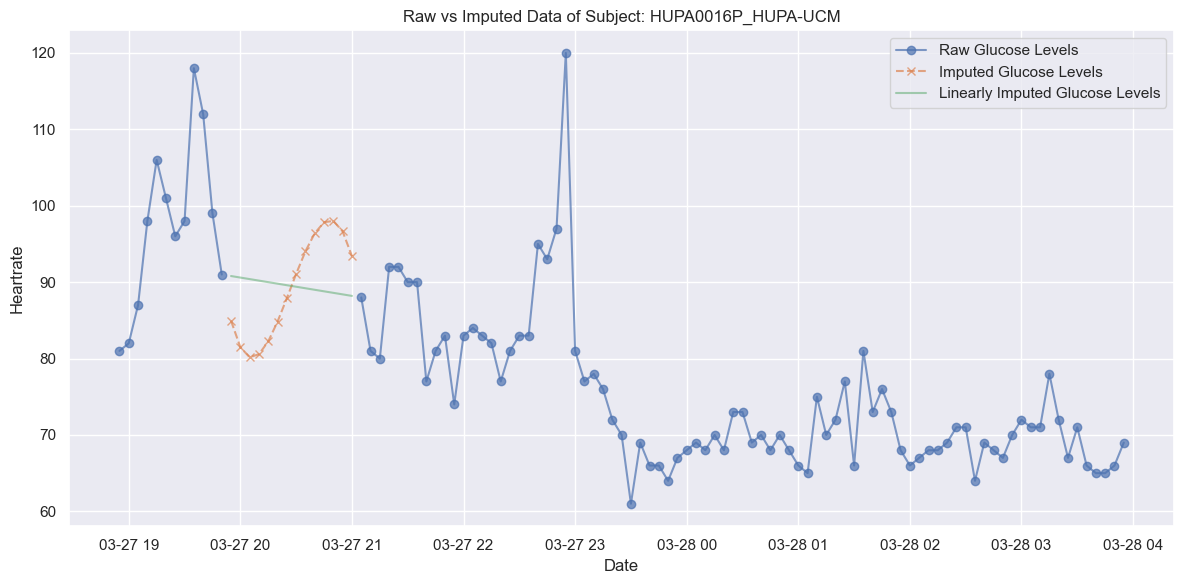

First 1-hour NaN gap starts at: 2019-03-28 20:40:00, ends at: 2019-03-28 21:35:00


/var/folders/t1/sgksm9r9385br4pts_lckj1w0000gn/T/ipykernel_3377/841181191.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  raw_week['date'] = pd.to_datetime(raw_week['ts'], format='%Y-%m-%d %H:%M:%S')


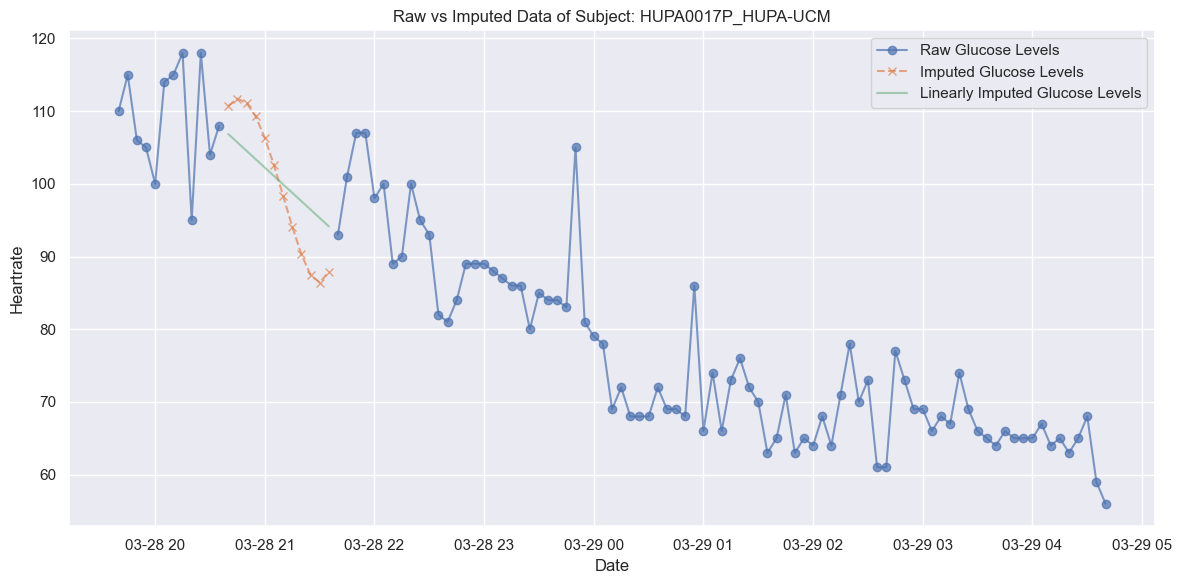

First 1-hour NaN gap starts at: 2019-07-07 10:35:00, ends at: 2019-07-07 11:55:00


/var/folders/t1/sgksm9r9385br4pts_lckj1w0000gn/T/ipykernel_3377/841181191.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  raw_week['date'] = pd.to_datetime(raw_week['ts'], format='%Y-%m-%d %H:%M:%S')


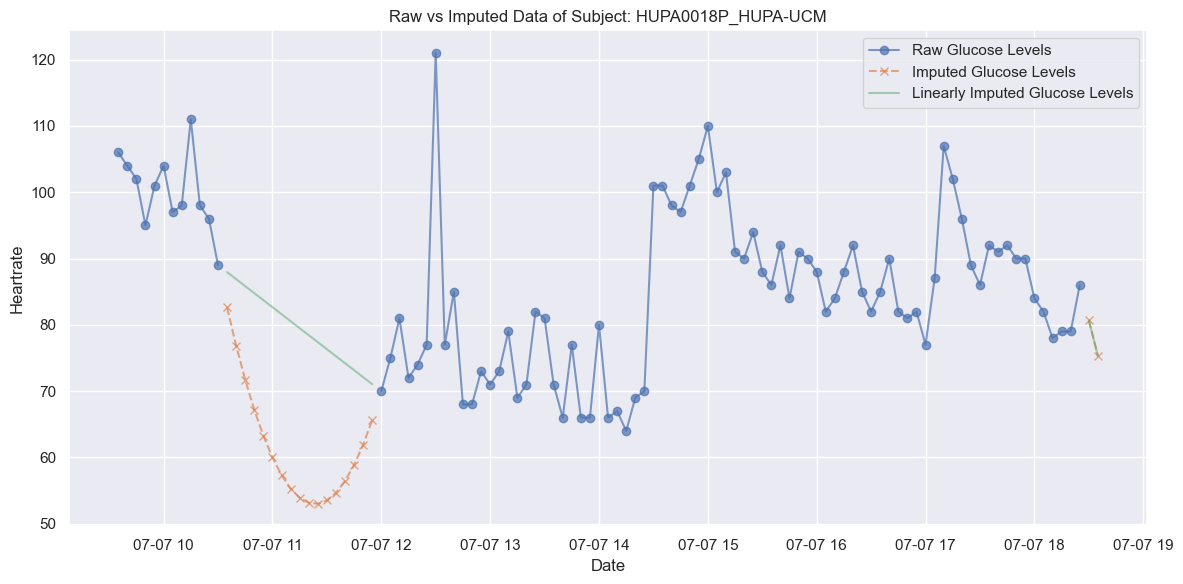

No 1-hour gap of continuous missing values found.
Non printable
First 1-hour NaN gap starts at: 2019-07-04 20:55:00, ends at: 2019-07-04 21:30:00


/var/folders/t1/sgksm9r9385br4pts_lckj1w0000gn/T/ipykernel_3377/841181191.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  raw_week['date'] = pd.to_datetime(raw_week['ts'], format='%Y-%m-%d %H:%M:%S')


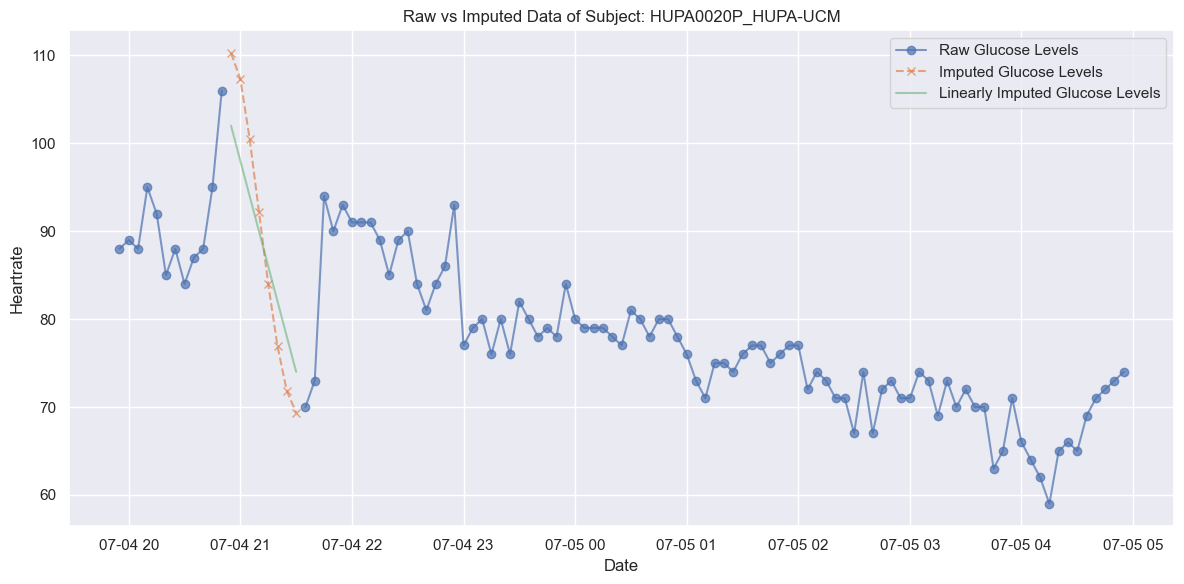

First 1-hour NaN gap starts at: 2019-07-03 10:45:00, ends at: 2019-07-03 12:20:00


/var/folders/t1/sgksm9r9385br4pts_lckj1w0000gn/T/ipykernel_3377/841181191.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  raw_week['date'] = pd.to_datetime(raw_week['ts'], format='%Y-%m-%d %H:%M:%S')


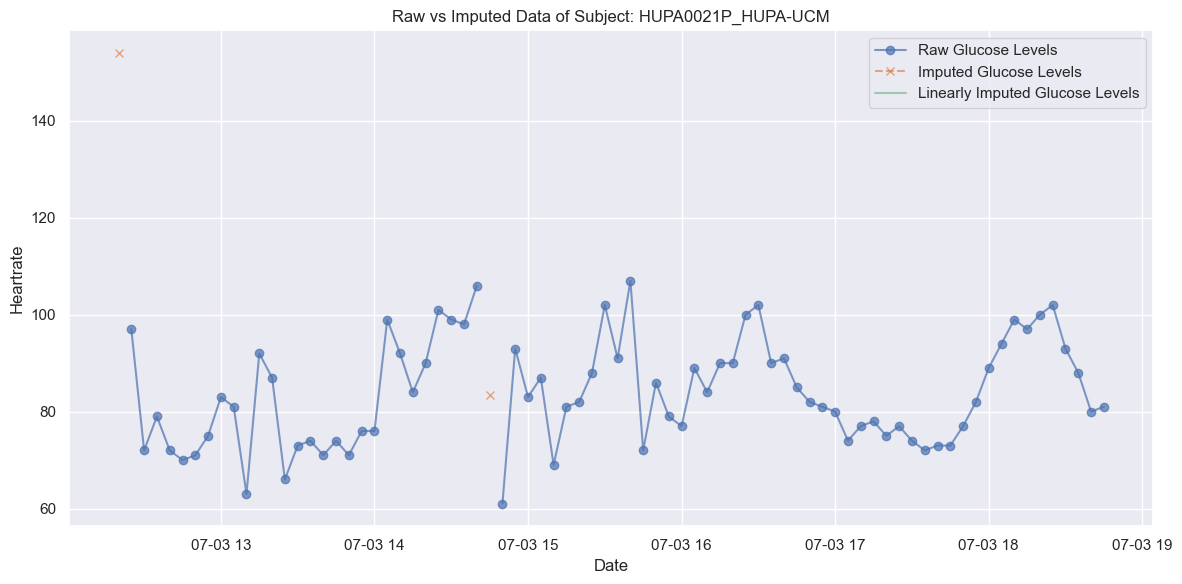

First 1-hour NaN gap starts at: 2020-01-19 15:05:00, ends at: 2020-01-19 16:40:00


/var/folders/t1/sgksm9r9385br4pts_lckj1w0000gn/T/ipykernel_3377/841181191.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  raw_week['date'] = pd.to_datetime(raw_week['ts'], format='%Y-%m-%d %H:%M:%S')


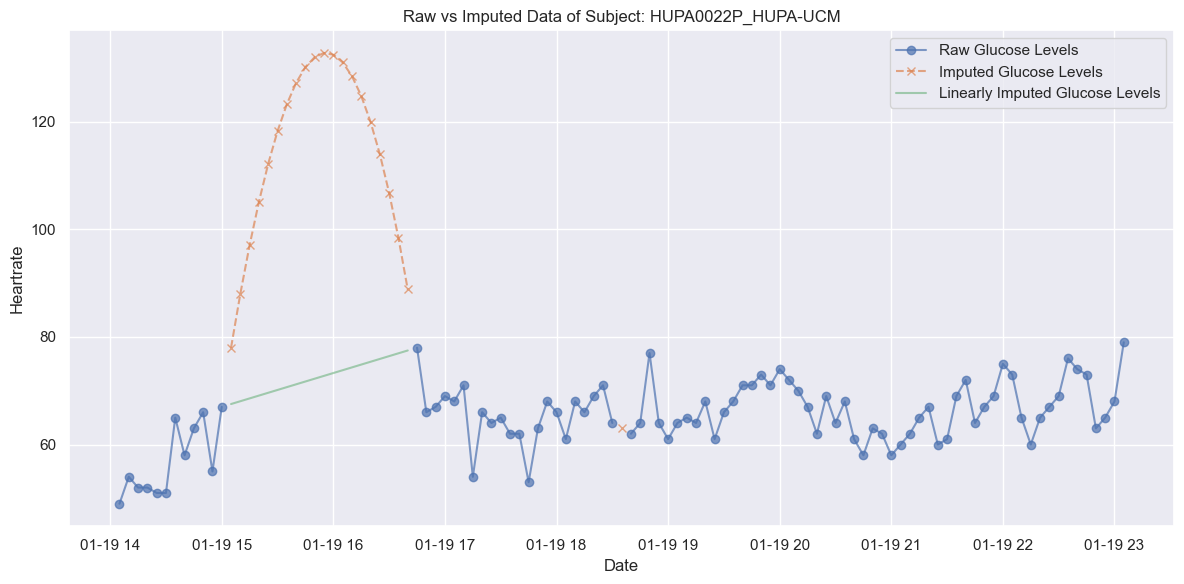

First 1-hour NaN gap starts at: 2020-01-18 13:35:00, ends at: 2020-01-18 14:35:00


/var/folders/t1/sgksm9r9385br4pts_lckj1w0000gn/T/ipykernel_3377/841181191.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  raw_week['date'] = pd.to_datetime(raw_week['ts'], format='%Y-%m-%d %H:%M:%S')


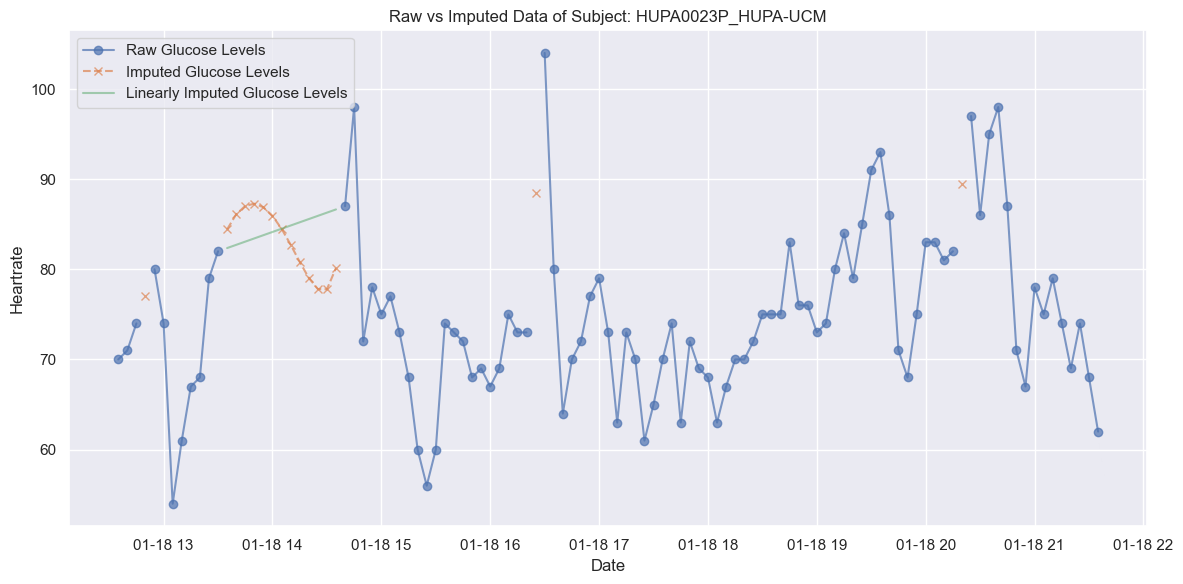

First 1-hour NaN gap starts at: 2020-01-26 09:15:00, ends at: 2020-01-26 10:00:00


/var/folders/t1/sgksm9r9385br4pts_lckj1w0000gn/T/ipykernel_3377/841181191.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  raw_week['date'] = pd.to_datetime(raw_week['ts'], format='%Y-%m-%d %H:%M:%S')


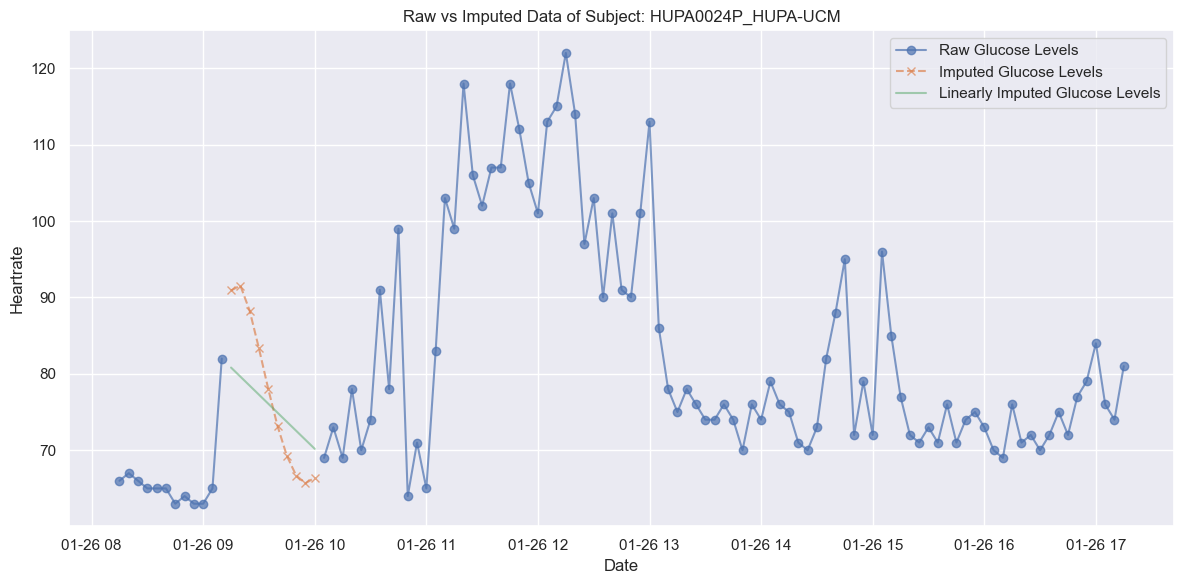

First 1-hour NaN gap starts at: 2020-01-16 12:45:00, ends at: 2020-01-16 13:10:00


/var/folders/t1/sgksm9r9385br4pts_lckj1w0000gn/T/ipykernel_3377/841181191.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  raw_week['date'] = pd.to_datetime(raw_week['ts'], format='%Y-%m-%d %H:%M:%S')


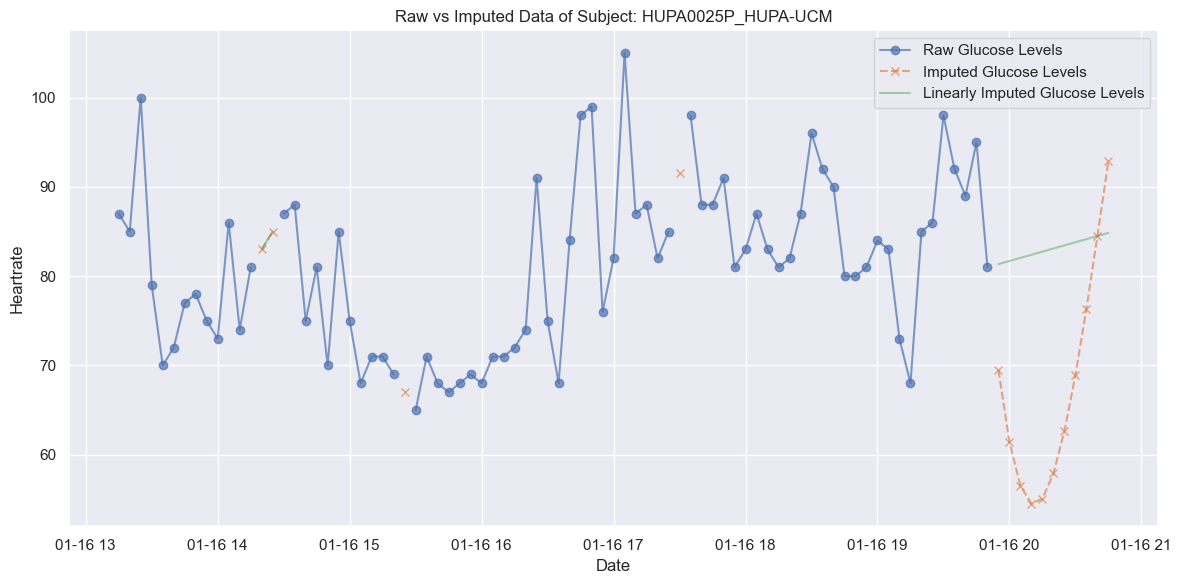

First 1-hour NaN gap starts at: 2020-05-16 19:40:00, ends at: 2020-05-16 20:15:00


/var/folders/t1/sgksm9r9385br4pts_lckj1w0000gn/T/ipykernel_3377/841181191.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  raw_week['date'] = pd.to_datetime(raw_week['ts'], format='%Y-%m-%d %H:%M:%S')


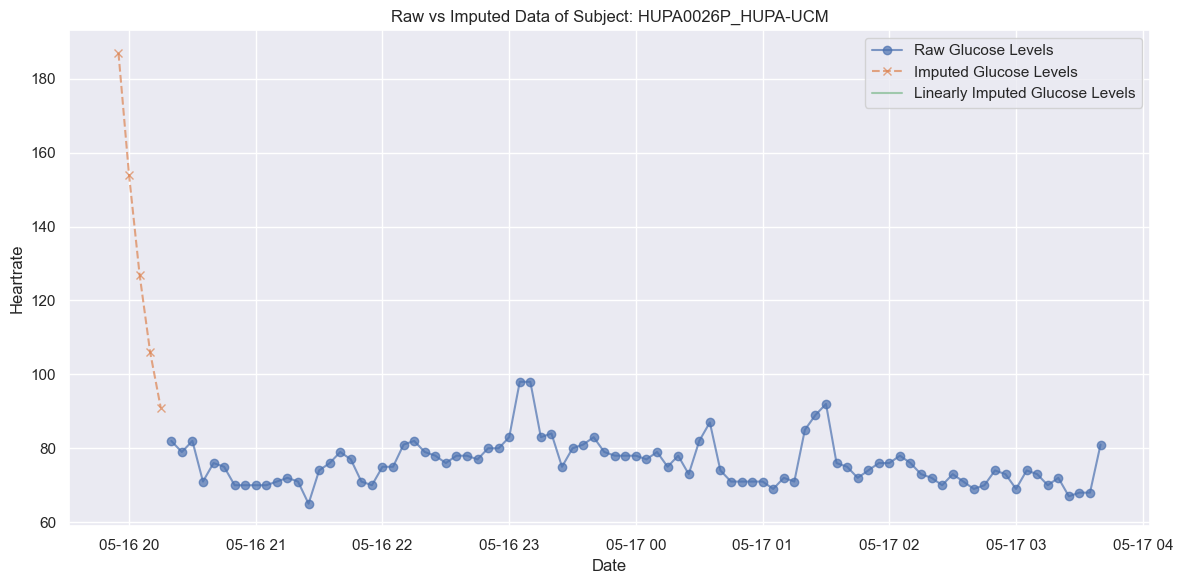

First 1-hour NaN gap starts at: 2020-06-30 08:10:00, ends at: 2020-06-30 09:00:00


/var/folders/t1/sgksm9r9385br4pts_lckj1w0000gn/T/ipykernel_3377/841181191.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  raw_week['date'] = pd.to_datetime(raw_week['ts'], format='%Y-%m-%d %H:%M:%S')


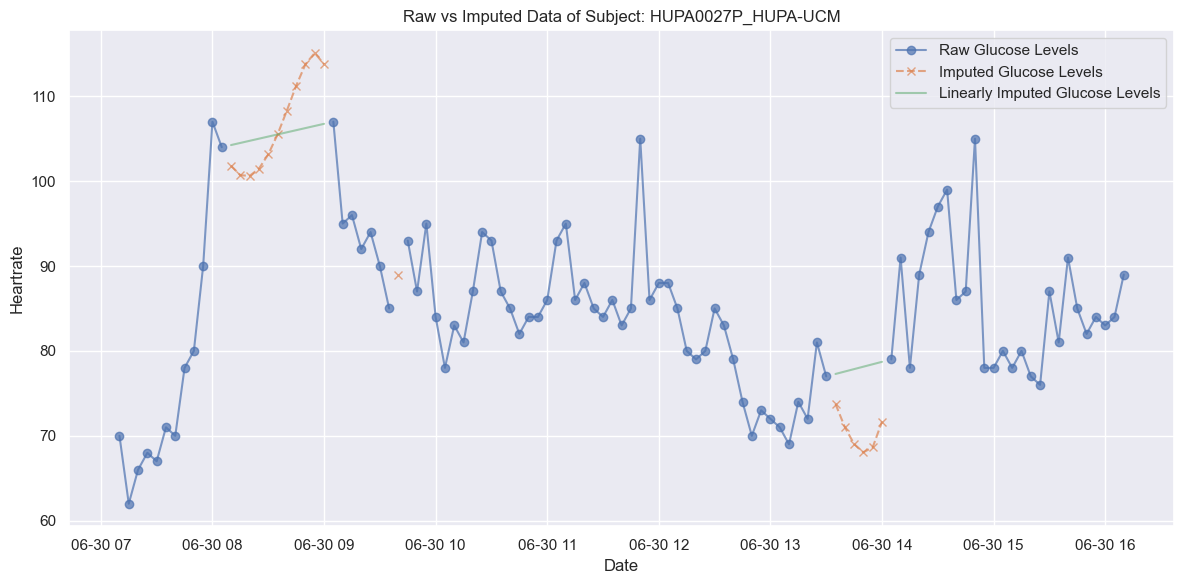

First 1-hour NaN gap starts at: 2022-02-17 14:55:00, ends at: 2022-02-17 15:25:00


/var/folders/t1/sgksm9r9385br4pts_lckj1w0000gn/T/ipykernel_3377/841181191.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  raw_week['date'] = pd.to_datetime(raw_week['ts'], format='%Y-%m-%d %H:%M:%S')


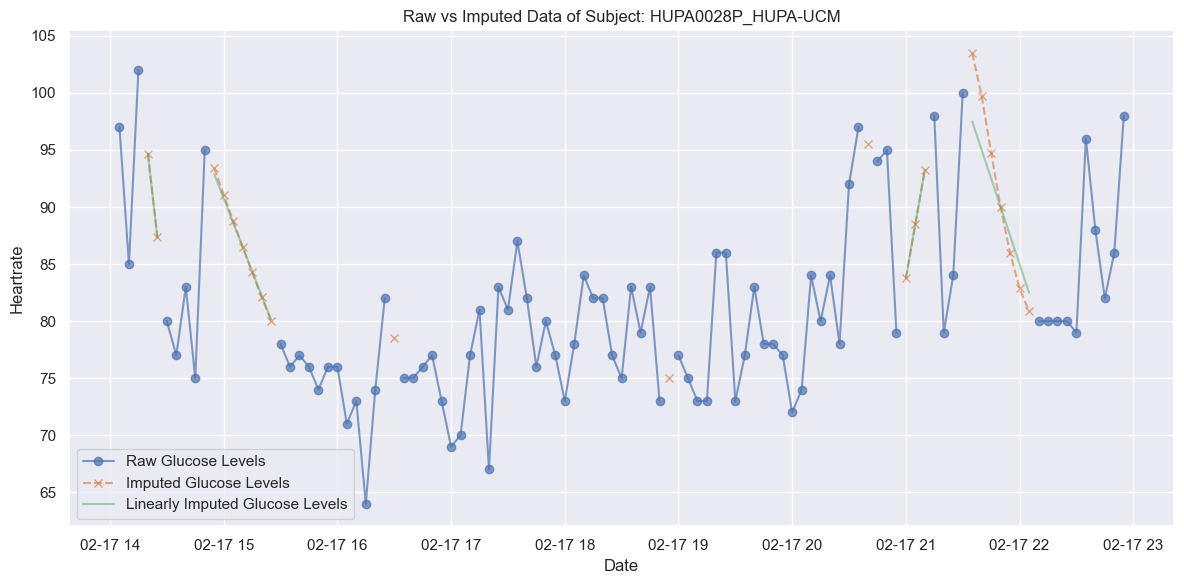

In [ ]:
subjects = subdatabaseII["PtID"].unique()
for i in subjects:
    print_missing(data_cleaned, sdbII_interpolated_stine, only_interpolated, i)

## Correlation Analysis with HR and GLC values

This section explores the correaltion between heartrate values and CGM values related to hypogylcemia up to 120 minutes before event onset

### Assign classes and generate time series

In [ ]:
# dataset with interpolated values is copied
classes_df = sdbII_interpolated_stine.copy()
# initially all classes are assigned a class -1
classes_df["Class"] = -1
# hypoglycemic values are defined as class 0 with values equal and lower than 70 mg/dL
classes_df.loc[classes_df["GlucoseCGM"] <= 70, "Class"] = 0

# calls the function class_generation to assing classes based on wanted intervals before hypogylcemia for each subject separately
classes_df = classes_df.groupby("PtID", group_keys=False).apply(lambda x: data_preprocessing.class_generation(x,"ts", 5, 15, 1)) # 5-15 min
classes_df = classes_df.groupby("PtID", group_keys=False).apply(lambda x: data_preprocessing.class_generation(x,"ts", 15, 30, 2)) # 15-30 min
classes_df = classes_df.groupby("PtID", group_keys=False).apply(lambda x: data_preprocessing.class_generation(x,"ts", 30, 60, 3))  # 30-60 min
classes_df = classes_df.groupby("PtID", group_keys=False).apply(lambda x: data_preprocessing.class_generation(x,"ts",  60, 125, 4)) # 1-2 h
classes_df.loc[classes_df["Class"] == -1, "Class"] = 5

# sorts the glucose values by patient id and timestamps
df_sorted = classes_df.sort_values(by=['PtID', 'ts'])
# reindexes based on the sorted dataset
df_sorted = df_sorted.reset_index(drop=True)

In [21]:
# prints the number of each value accross classes
df_sorted["Class"].value_counts()

Class
5    1480967
0      39842
4      39028
3      20174
2      10726
1       7416
Name: count, dtype: int64

### Normalization

In [22]:
# normalizes data 
df_min_max_scaled = data_preprocessing.normalize_data(df_sorted, 'GlucoseCGM')
df_min_max_scaled = data_preprocessing.normalize_data(df_min_max_scaled, 'HR')	 

### Correlation Analysis

In [23]:
output_file = "correlation_results.txt"

with open(output_file, "w") as f:
    # applies correlation analysis between glucose and heart rate values for the whole dataset
    f.write("=== Correlation for Whole Dataset ===\n")
    f.write(f"Pearson:  {df_min_max_scaled['GlucoseCGM'].corr(df_min_max_scaled['HR'], method='pearson'):.4f}\n")
    f.write(f"Spearman: {df_min_max_scaled['GlucoseCGM'].corr(df_min_max_scaled['HR'], method='spearman'):.4f}\n")
    f.write(f"Kendall:  {df_min_max_scaled['GlucoseCGM'].corr(df_min_max_scaled['HR'], method='kendall'):.4f}\n\n")

    # applies correlation analysis between glucose and heart rate values for the assigned classes
    f.write("=== Correlation by Class ===\n")

    for method in ["pearson", "spearman", "kendall"]:
        cor_by_class = df_min_max_scaled.groupby("Class").apply(
            lambda g: g["GlucoseCGM"].corr(g["HR"], method=method)
        )
        f.write(f"\n{method.capitalize()} correlation:\n")
        f.write(cor_by_class.to_string())
        f.write("\n")

print(f"\n Correlation results saved to: {output_file}")


 Correlation results saved to: correlation_results.txt


In [24]:
# applies correlation analysis between glucose and heart rate values for the whole dataset
print(df_min_max_scaled['GlucoseCGM'].corr(df_min_max_scaled['HR'], method = "pearson"))
print(df_min_max_scaled['GlucoseCGM'].corr(df_min_max_scaled['HR'], method = "spearman"))
print(df_min_max_scaled['GlucoseCGM'].corr(df_min_max_scaled['HR'], method = "kendall"))
# applies correlation analysis between glucose and heart rate values for the assigned classes
pearson_by_class = df_min_max_scaled.groupby('Class').apply(lambda g: g['GlucoseCGM'].corr(g['HR'], method = "pearson"))
print(pearson_by_class)
spearman_by_class = df_min_max_scaled.groupby('Class').apply(lambda g: g['GlucoseCGM'].corr(g['HR'], method = "spearman"))
print(spearman_by_class)
kendall_by_class = df_min_max_scaled.groupby('Class').apply(lambda g: g['GlucoseCGM'].corr(g['HR'], method = "kendall"))
print(kendall_by_class)

0.0663807514085974
0.06515928647464347
0.043841650349741336
Class
0    0.125562
1    0.200122
2    0.287205
3    0.233134
4    0.169013
5    0.083111
dtype: float64
Class
0    0.117417
1    0.195105
2    0.300425
3    0.266303
4    0.204796
5    0.084184
dtype: float64
Class
0    0.078621
1    0.134037
2    0.206937
3    0.183050
4    0.139915
5    0.056657
dtype: float64


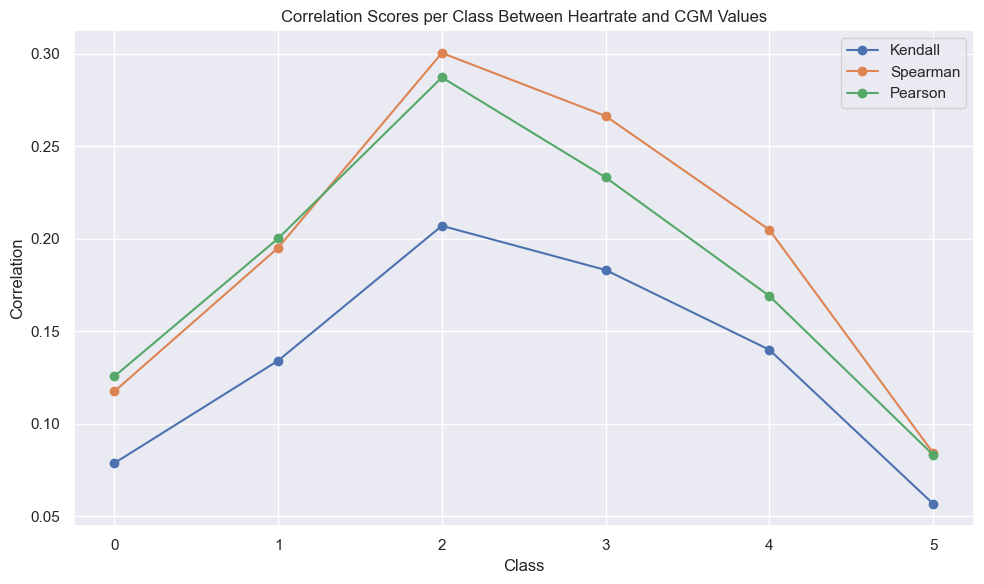

In [25]:
# plots the correaltion scores for each method and each class
df_correlations = pd.DataFrame({
    "Kendall": kendall_by_class,
    "Spearman": spearman_by_class,
    "Pearson": pearson_by_class
}).T

df_correlations.T.plot(marker='o', figsize=(10, 6)) 
plt.title("Correlation Scores per Class Between Heartrate and CGM Values")
plt.xlabel("Class")
plt.ylabel("Correlation")
plt.tight_layout()
plt.show()